## Final Model Evaluation 

In [12]:
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score
)
from sklearn.calibration import calibration_curve
from lifelines import KaplanMeierFitter
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

OUTPUT_DIR = Path('C:/Users/20220505/Desktop/output path')
FIG_DIR    = OUTPUT_DIR / 'figures_04'
FIG_DIR.mkdir(exist_ok=True)

HORIZONS  = [6, 12, 24]
NUM_BINS  = 48
MAX_HOURS = 200
time_cuts = np.linspace(0, MAX_HOURS, NUM_BINS + 1)[1:]

def savefig(name):
    plt.savefig(str(FIG_DIR / f'{name}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {name}.png ✓')

print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'FIG_DIR    : {FIG_DIR}')
print('Setup complete ✓')

OUTPUT_DIR : C:\Users\20220505\Desktop\output path
FIG_DIR    : C:\Users\20220505\Desktop\output path\figures_04
Setup complete ✓


In [13]:
print('Loading all outputs...')

# ── DDH ───────────────────────────────────────────────────────
surv_ddh_inc = np.load(str(OUTPUT_DIR / 'ddh_incident_surv_calibrated.npy'))
surv_ddh_all = np.load(str(OUTPUT_DIR / 'ddh_all_surv_cal.npy'))
dur_ddh_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_dur.npy'))
evt_ddh_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_evt.npy'))
dur_ddh_all  = np.load(str(OUTPUT_DIR / 'ddh_all_dur.npy'))
evt_ddh_all  = np.load(str(OUTPUT_DIR / 'ddh_all_evt.npy'))

# ── TransformerSurvival ───────────────────────────────────────
surv_t_inc = np.load(str(OUTPUT_DIR / 'transformer_incident_surv_cal.npy'))
surv_t_all = np.load(str(OUTPUT_DIR / 'transformer_all_surv_cal.npy'))
dur_t_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_dur.npy'))
evt_t_inc  = np.load(str(OUTPUT_DIR / 'transformer_incident_evt.npy'))
dur_t_all  = np.load(str(OUTPUT_DIR / 'transformer_all_dur.npy'))
evt_t_all  = np.load(str(OUTPUT_DIR / 'transformer_all_evt.npy'))

# ── DST v2 (incident training + Platt calibration) ───────────
surv_dst_all = np.load(str(OUTPUT_DIR / 'dst_surv_cal.npy'))
dur_dst_all  = np.load(str(OUTPUT_DIR / 'dst_dur_test.npy'))
evt_dst_all  = np.load(str(OUTPUT_DIR / 'dst_evt_test.npy'))

# DST test set IS incident only — no masking needed
surv_dst_inc = surv_dst_all
dur_dst_inc  = dur_dst_all
evt_dst_inc  = evt_dst_all

# ── Old SHAP (DDH) ────────────────────────────────────────────
shap_values  = np.load(str(OUTPUT_DIR / 'shap_values_ddh.npy'))
shap_times   = np.load(str(OUTPUT_DIR / 'shap_times.npy'))

# ── New SHAP (DST v2 GradientSHAP) ───────────────────────────
dst_shap_values   = np.load(str(OUTPUT_DIR / 'dst_shap_values.npy'))
dst_shap_stay_ids = np.load(str(OUTPUT_DIR / 'dst_shap_stay_ids.npy'))
dst_shap_meta     = pd.read_csv(str(OUTPUT_DIR / 'dst_shap_meta.csv'))

# ── Metadata ──────────────────────────────────────────────────
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_cols = f.read().splitlines()
with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()
with open(OUTPUT_DIR / 'results_summary.json') as f:
    results_summary = json.load(f)
with open(OUTPUT_DIR / 'dst_results.json') as f:
    dst_results = json.load(f)

horizon_results = joblib.load(str(OUTPUT_DIR / 'horizon_results_full.pkl'))
survival_df     = pd.read_csv(str(OUTPUT_DIR / 'survival_dataset.csv'))
survival_inc    = pd.read_csv(str(OUTPUT_DIR / 'survival_incident_dataset.csv'))

# ── Rolling predictions ───────────────────────────────────────
rolling_df = pd.read_csv(str(OUTPUT_DIR / 'rolling_predictions.csv'))
with open(OUTPUT_DIR / 'rolling_results.json') as f:
    rolling_results = json.load(f)

hl = pd.read_csv(str(OUTPUT_DIR / 'hourly_labels.csv'))
onset_lookup = (
    hl[hl['label'] == 1]
    .groupby('stay_id')['hour'].min()
    .to_dict()
)

# ── Platt calibration helper (needed for DST figures) ─────────
from sklearn.linear_model import LogisticRegression
def apply_platt_calibration(surv, calibrators, num_bins):
    surv_cal      = surv.copy()
    cal_t_indices = sorted(calibrators.keys())
    for t_idx in cal_t_indices:
        lr       = calibrators[t_idx]
        pred_cif = (1 - surv_cal[:, t_idx]).clip(0, 1).reshape(-1, 1)
        cal_cif  = lr.predict_proba(pred_cif)[:, 1].clip(0, 1)
        surv_cal[:, t_idx] = 1 - cal_cif
    for t in range(num_bins):
        if t not in calibrators:
            lo = max([k for k in cal_t_indices if k <= t], default=None)
            hi = min([k for k in cal_t_indices if k >= t], default=None)
            if lo is not None and hi is not None and lo != hi:
                w = (t - lo) / (hi - lo)
                surv_cal[:, t] = (1-w)*surv_cal[:, lo] + w*surv_cal[:, hi]
            elif lo is not None:
                surv_cal[:, t] = surv_cal[:, lo]
            elif hi is not None:
                surv_cal[:, t] = surv_cal[:, hi]
    for t in range(1, num_bins):
        surv_cal[:, t] = np.minimum(surv_cal[:, t], surv_cal[:, t-1])
    return surv_cal

print(f'\nArrays loaded:')
print(f'  surv_ddh_inc   : {surv_ddh_inc.shape}')
print(f'  surv_t_inc     : {surv_t_inc.shape}')
print(f'  surv_t_all     : {surv_t_all.shape}')
print(f'  surv_dst_all   : {surv_dst_all.shape}')
print(f'  surv_dst_inc   : {surv_dst_inc.shape}')
print(f'  shap_values    : {shap_values.shape}  (DDH — old)')
print(f'  dst_shap_values: {dst_shap_values.shape}  (DST v2 — new)')
print(f'  feature_cols   : {len(feature_cols)}')
print(f'  rolling_df     : {rolling_df.shape}')
print(f'\nAll outputs loaded ✓')

Loading all outputs...

Arrays loaded:
  surv_ddh_inc   : (7310, 48)
  surv_t_inc     : (7310, 48)
  surv_t_all     : (10604, 48)
  surv_dst_all   : (7887, 48)
  surv_dst_inc   : (7887, 48)
  shap_values    : (7887, 127, 12)  (DDH — old)
  dst_shap_values: (500, 127)  (DST v2 — new)
  feature_cols   : 127
  rolling_df     : (2500579, 6)

All outputs loaded ✓


In [18]:
from pycox.evaluation import EvalSurv

print('Computing bootstrap CIs (1000 resamples)...')
print('This takes ~2-3 minutes...')

N_BOOTSTRAP = 1000
RNG         = np.random.default_rng(42)

def surv_to_df(surv, cuts):
    return pd.DataFrame(surv.T, index=cuts)

def compute_ci(surv, dur, evt, cuts):
    ev = EvalSurv(surv_to_df(surv, cuts), dur, evt, censor_surv='km')
    return ev.concordance_td()

def compute_ibs(surv, dur, evt, cuts):
    ev          = EvalSurv(surv_to_df(surv, cuts), dur, evt, censor_surv='km')
    event_times = dur[evt == 1]
    t_min       = np.percentile(event_times, 5)
    t_max       = np.percentile(event_times, 95)
    return ev.integrated_brier_score(np.linspace(t_min, t_max, 100))

def bootstrap_metric(fn, surv, dur, evt, cuts, n=N_BOOTSTRAP):
    scores    = []
    n_samples = len(dur)
    for _ in range(n):
        idx = RNG.integers(0, n_samples, size=n_samples)
        if evt[idx].sum() == 0:
            continue
        try:
            scores.append(fn(surv[idx], dur[idx], evt[idx], cuts))
        except Exception:
            continue
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

models = [
    ('DDH (cal)',         'Incident',   surv_ddh_inc, dur_ddh_inc, evt_ddh_inc),
    ('DDH (cal)',         'All Sepsis', surv_ddh_all, dur_ddh_all, evt_ddh_all),
    ('Transformer (cal)', 'Incident',   surv_t_inc,   dur_t_inc,   evt_t_inc),
    ('Transformer (cal)', 'All Sepsis', surv_t_all,   dur_t_all,   evt_t_all),
    ('DST v2 (cal)',      'Incident',   surv_dst_inc, dur_dst_inc, evt_dst_inc),
    ('DST v2 (cal)',      'All Sepsis', surv_dst_all, dur_dst_all, evt_dst_all),
]

rows = []
for model_name, dataset, surv, dur, evt in models:
    print(f'\n  {model_name} | {dataset}')
    ci_pt  = compute_ci(surv, dur, evt, time_cuts)
    ibs_pt = compute_ibs(surv, dur, evt, time_cuts)
    ci_mu,  ci_lo,  ci_hi  = bootstrap_metric(compute_ci,  surv, dur, evt, time_cuts)
    ibs_mu, ibs_lo, ibs_hi = bootstrap_metric(compute_ibs, surv, dur, evt, time_cuts)
    rows.append({
        'Model'      : model_name,
        'Dataset'    : dataset,
        'C-index'    : round(ci_pt,  4),
        'CI_lo'      : round(ci_lo,  4),
        'CI_hi'      : round(ci_hi,  4),
        'IBS'        : round(ibs_pt, 4),
        'IBS_lo'     : round(ibs_lo, 4),
        'IBS_hi'     : round(ibs_hi, 4),
        'N_test'     : len(dur),
        'N_events'   : int(evt.sum()),
        'Event_rate' : round(evt.mean(), 4),
    })
    print(f'    C-index : {ci_pt:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
    print(f'    IBS     : {ibs_pt:.4f}  95% CI [{ibs_lo:.4f}, {ibs_hi:.4f}]')

bootstrap_df = pd.DataFrame(rows)
bootstrap_df.to_csv(str(OUTPUT_DIR / 'bootstrap_results.csv'), index=False)
print('\nSaved -> bootstrap_results.csv ✓')

Computing bootstrap CIs (1000 resamples)...
This takes ~2-3 minutes...

  DDH (cal) | Incident
    C-index : 0.9245  95% CI [0.9120, 0.9355]
    IBS     : 0.0528  95% CI [0.0436, 0.0625]

  DDH (cal) | All Sepsis
    C-index : 0.9492  95% CI [0.9460, 0.9526]
    IBS     : 0.0114  95% CI [0.0105, 0.0127]

  Transformer (cal) | Incident
    C-index : 0.9314  95% CI [0.9189, 0.9425]
    IBS     : 0.0484  95% CI [0.0395, 0.0560]

  Transformer (cal) | All Sepsis
    C-index : 0.9822  95% CI [0.9806, 0.9839]
    IBS     : 0.0104  95% CI [0.0097, 0.0116]

  DST v2 (cal) | Incident
    C-index : 0.9790  95% CI [0.9760, 0.9818]
    IBS     : 0.0477  95% CI [0.0391, 0.0558]

  DST v2 (cal) | All Sepsis
    C-index : 0.9790  95% CI [0.9759, 0.9815]
    IBS     : 0.0477  95% CI [0.0394, 0.0556]

Saved -> bootstrap_results.csv ✓


In [19]:
from scipy import stats

def delong_roc_variance(y_true, y_score):
    pos  = y_score[y_true == 1]
    neg  = y_score[y_true == 0]
    n_p, n_n = len(pos), len(neg)
    m10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
    m01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
    auc = m10.mean()
    var = np.var(m10, ddof=1) / n_p + np.var(m01, ddof=1) / n_n
    return auc, var

def delong_compare(y_true, score_a, score_b):
    auc_a, var_a = delong_roc_variance(y_true, score_a)
    auc_b, var_b = delong_roc_variance(y_true, score_b)
    z = (auc_a - auc_b) / np.sqrt(var_a + var_b + 1e-12)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b

def get_horizon_scores(surv, dur, evt, H):
    bin_H   = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS-1))
    y_true  = ((evt == 1) & (dur <= H)).astype(int)
    y_score = (1 - surv[:, bin_H]).clip(0, 1)
    return y_true, y_score

print('DeLong tests — DDH vs Transformer\n')
delong_rows = []

for dataset_label, surv_d, dur_d, evt_d, surv_t, dur_t, evt_t in [
    ('Incident',   surv_ddh_inc, dur_ddh_inc, evt_ddh_inc, surv_t_inc, dur_t_inc, evt_t_inc),
    ('All Sepsis', surv_ddh_all, dur_ddh_all, evt_ddh_all, surv_t_all, dur_t_all, evt_t_all),
]:
    print(f'{dataset_label}:')
    print(f"{'Horizon':>8} | {'AUROC DDH':>10} | {'AUROC Transf':>12} | {'Z':>6} | {'p-value':>8} | {'Sig':>5}")
    print('-' * 60)
    for H in HORIZONS:
        yt_d, ys_d = get_horizon_scores(surv_d, dur_d, evt_d, H)
        yt_t, ys_t = get_horizon_scores(surv_t, dur_t, evt_t, H)
        if yt_d.sum() < 5:
            continue
        z, p, auc_d, auc_t = delong_compare(yt_d, ys_d, ys_t)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        delong_rows.append({
            'Horizon_h'   : H,
            'Dataset'     : dataset_label,
            'AUROC_DDH'   : round(auc_d, 4),
            'AUROC_Transf': round(auc_t, 4),
            'Z'           : round(z, 3),
            'p_value'     : round(p, 4),
            'Significance': sig,
        })
        print(f'  @{H:>2}h   | {auc_d:>10.4f} | {auc_t:>12.4f} | {z:>6.3f} | {p:>8.4f} | {sig:>5}')
    print()

delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(str(OUTPUT_DIR / 'delong_results.csv'), index=False)
print('Saved -> delong_results.csv ✓')

DeLong tests — DDH vs Transformer

Incident:
 Horizon |  AUROC DDH | AUROC Transf |      Z |  p-value |   Sig
------------------------------------------------------------
  @ 6h   |     0.9868 |       0.9899 | -1.749 |   0.0804 |    ns
  @12h   |     0.9953 |       0.9995 | -4.771 |   0.0000 |   ***
  @24h   |     0.9622 |       0.9690 | -0.876 |   0.3810 |    ns

All Sepsis:
 Horizon |  AUROC DDH | AUROC Transf |      Z |  p-value |   Sig
------------------------------------------------------------
  @ 6h   |     0.9993 |       0.9999 | -3.069 |   0.0021 |    **
  @12h   |     0.9994 |       1.0000 | -2.609 |   0.0091 |    **
  @24h   |     0.9964 |       0.9968 | -0.397 |   0.6914 |    ns

Saved -> delong_results.csv ✓


In [22]:
print('Building master results table...')

key_map = {
        ('DDH (cal)',         'Incident')  : 'DDH (calibrated)|Incident',
        ('DDH (cal)',         'All Sepsis'): 'DDH (calibrated)|All Sepsis',
        ('Transformer (cal)', 'Incident')  : 'Transformer (cal)|Incident',
        ('Transformer (cal)', 'All Sepsis'): 'Transformer (cal)|All Sepsis',
        ('DST v2 (cal)',      'Incident')  : '',
        ('DST v2 (cal)',      'All Sepsis'): '',
    }

master_rows = []
for _, br in bootstrap_df.iterrows():
    hkey = key_map.get((br['Model'], br['Dataset']), '')
    row  = {
        'Model'        : br['Model'],
        'Dataset'      : br['Dataset'],
        'N_test'       : br['N_test'],
        'N_events'     : br['N_events'],
        'Event_rate'   : br['Event_rate'],
        'C-index'      : br['C-index'],
        'C-index_95CI' : f"[{br['CI_lo']}, {br['CI_hi']}]",
        'IBS'          : br['IBS'],
        'IBS_95CI'     : f"[{br['IBS_lo']}, {br['IBS_hi']}]",
    }
    for H in HORIZONS:
        if hkey and hkey in horizon_results:
            r = horizon_results[hkey].get(H, {})
            row[f'AUROC@{H}h'] = round(r.get('auroc', np.nan), 4)
            row[f'AUPRC@{H}h'] = round(r.get('auprc', np.nan), 4)
        else:
            row[f'AUROC@{H}h'] = None
            row[f'AUPRC@{H}h'] = None
    master_rows.append(row)

# ── Fill DST AUROC from direct computation ────────────────────
for row in master_rows:
    if 'DST' not in row['Model']:
        continue
    if row['Dataset'] == 'Incident':
        surv, dur, evt = surv_dst_inc, dur_dst_inc, evt_dst_inc
    else:
        surv, dur, evt = surv_dst_all, dur_dst_all, evt_dst_all
    for H in HORIZONS:
        bin_H   = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS-1))
        y_true  = ((evt==1) & (dur<=H)).astype(int)
        y_score = (1 - surv[:, bin_H]).clip(0, 1)
        if y_true.sum() >= 5:
            row[f'AUROC@{H}h'] = round(roc_auc_score(y_true, y_score), 4)
            row[f'AUPRC@{H}h'] = round(average_precision_score(y_true, y_score), 4)
master_df = pd.DataFrame(master_rows)
master_df.to_csv(str(OUTPUT_DIR / 'master_results.csv'), index=False)
print('Saved -> master_results.csv ✓')

try:
    import openpyxl
    with pd.ExcelWriter(str(OUTPUT_DIR / 'master_results.xlsx'), engine='openpyxl') as writer:
        master_df.to_excel(writer, sheet_name='Results', index=False)
        bootstrap_df.to_excel(writer, sheet_name='Bootstrap_CIs', index=False)
        delong_df.to_excel(writer, sheet_name='DeLong_Tests', index=False)
    print('Saved -> master_results.xlsx ✓')
except Exception as e:
    print(f'Excel save skipped: {e}')

print('\n' + '='*70)
print('SURVIVAL MODEL MASTER RESULTS')
print('='*70)
display_cols = ['Model', 'Dataset', 'C-index', 'C-index_95CI', 'IBS', 'AUROC@6h', 'AUROC@12h', 'AUROC@24h']
print(master_df[display_cols].to_string(index=False))
print('='*70)

Building master results table...
Saved -> master_results.csv ✓
Saved -> master_results.xlsx ✓

SURVIVAL MODEL MASTER RESULTS
            Model    Dataset  C-index     C-index_95CI    IBS  AUROC@6h  AUROC@12h  AUROC@24h
        DDH (cal)   Incident   0.9245  [0.912, 0.9355] 0.0528    0.9868     0.9953     0.9622
        DDH (cal) All Sepsis   0.9492  [0.946, 0.9526] 0.0114    0.9993     0.9994     0.9964
Transformer (cal)   Incident   0.9314 [0.9189, 0.9425] 0.0484    0.9899     0.9995     0.9690
Transformer (cal) All Sepsis   0.9822 [0.9806, 0.9839] 0.0104    0.9999     1.0000     0.9968
     DST v2 (cal)   Incident   0.9790  [0.976, 0.9818] 0.0477    0.9935     0.9963     0.9854
     DST v2 (cal) All Sepsis   0.9790 [0.9759, 0.9815] 0.0477    0.9935     0.9963     0.9854


Building rolling window evaluation figures...


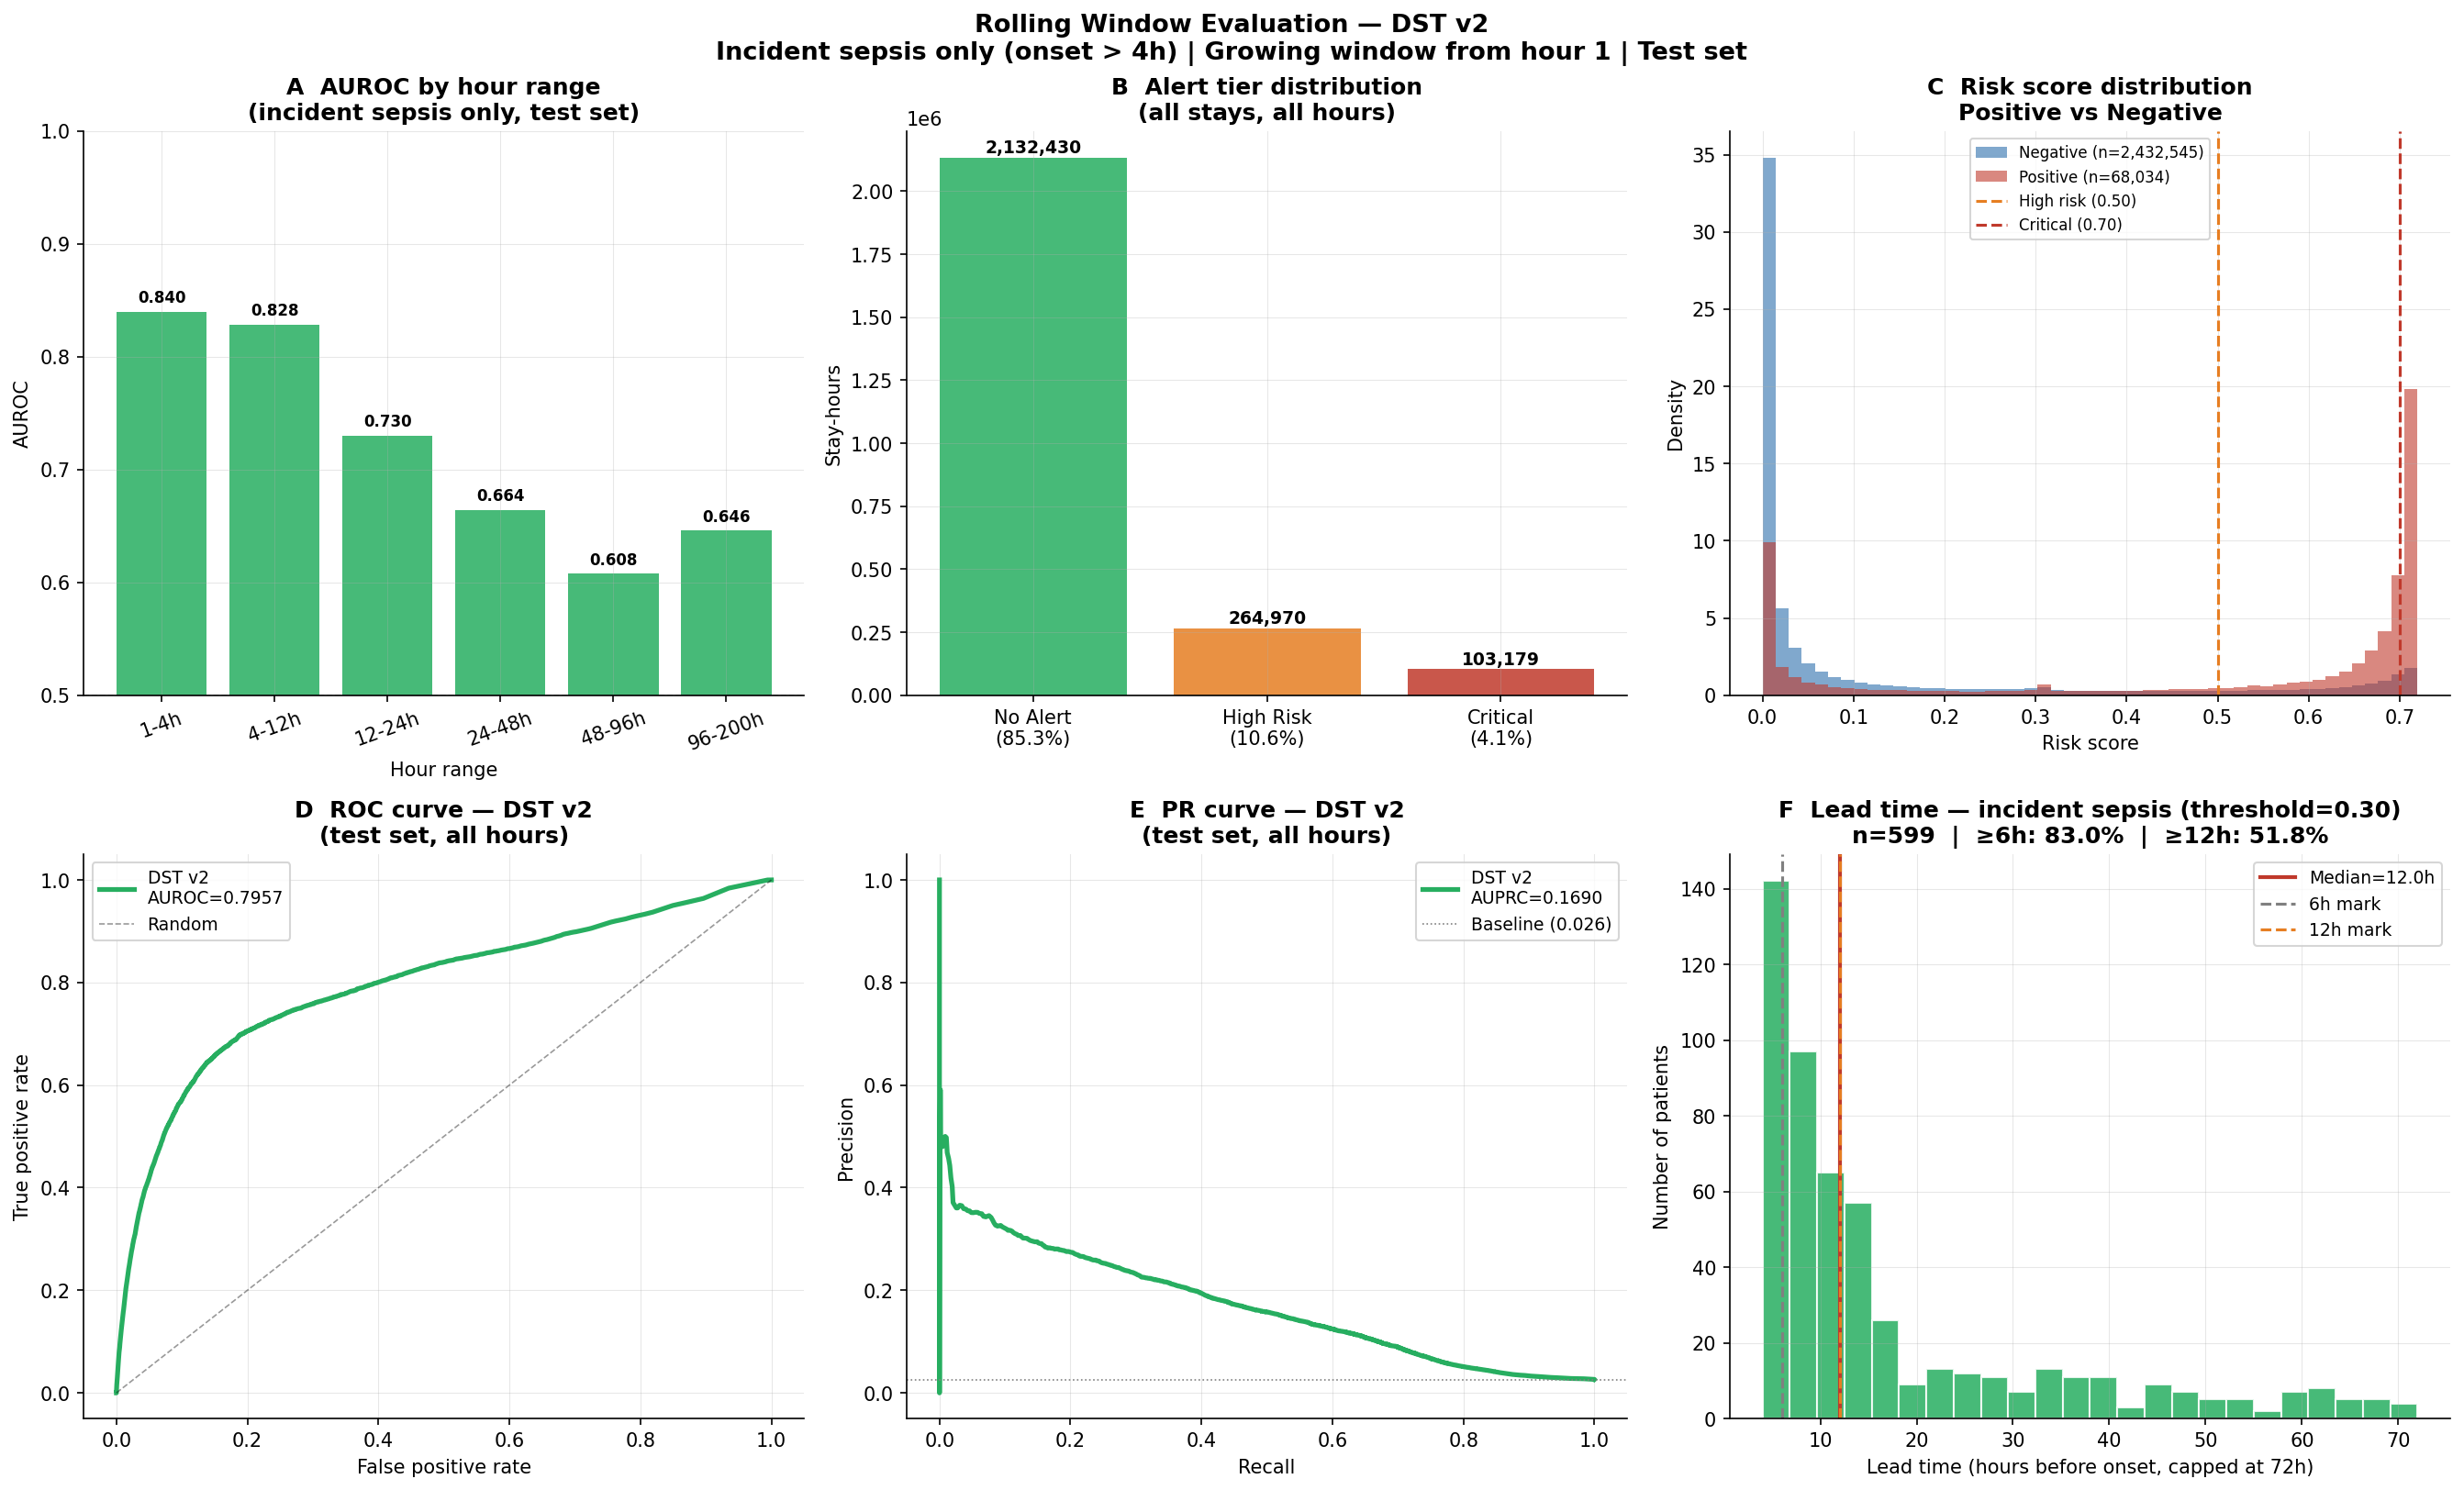

Saved -> fig10_dst_rolling_evaluation.png ✓

Section 6 complete ✓


In [23]:
# ============================================================
# Cell 6a: Rolling window evaluation figures — DST v2
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
print("Building rolling window evaluation figures...")

test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Rolling Window Evaluation — DST v2\n'
    'Incident sepsis only (onset > 4h) | Growing window from hour 1 | Test set',
    fontsize=13, fontweight='bold'
)

# ── Panel A: AUROC by hour range ──────────────────────────────
ax = axes[0, 0]
bins       = [(1,4),(4,12),(12,24),(24,48),(48,96),(96,200)]
bin_labels = ['1-4h','4-12h','12-24h','24-48h','48-96h','96-200h']
aurocs     = []
for lo, hi in bins:
    sub   = test_inc[(test_inc['hour'] >= lo) & (test_inc['hour'] < hi)]
    n_pos = sub['true_label_12h'].sum()
    if n_pos >= 10 and (len(sub)-n_pos) >= 10:
        aurocs.append(roc_auc_score(sub['true_label_12h'], sub['risk_score']))
    else:
        aurocs.append(np.nan)

colors_bar = ['#27AE60' if not np.isnan(v) else '#cccccc' for v in aurocs]
bars = ax.bar(bin_labels, aurocs, color=colors_bar, alpha=0.85)
for bar, v in zip(bars, aurocs):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Hour range')
ax.set_ylabel('AUROC')
ax.set_title('A  AUROC by hour range\n(incident sepsis only, test set)', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# ── Panel B: Alert tier distribution ─────────────────────────
ax = axes[0, 1]
tier_counts = rolling_df['alert_tier'].value_counts()
tier_order  = ['no_alert', 'high_risk', 'critical']
tier_colors = ['#27AE60', '#E67E22', '#C0392B']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
tier_labels = [f'No Alert\n({tier_vals[0]/len(rolling_df):.1%})',
               f'High Risk\n({tier_vals[1]/len(rolling_df):.1%})',
               f'Critical\n({tier_vals[2]/len(rolling_df):.1%})']
bars = ax.bar(tier_labels, tier_vals, color=tier_colors, alpha=0.85)
for bar, v in zip(bars, tier_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Stay-hours')
ax.set_title('B  Alert tier distribution\n(all stays, all hours)', fontweight='bold')

# ── Panel C: Risk score distribution ─────────────────────────
ax = axes[0, 2]
pos_scores = rolling_df[rolling_df['true_label_12h'] == 1]['risk_score']
neg_scores = rolling_df[rolling_df['true_label_12h'] == 0]['risk_score']
ax.hist(neg_scores, bins=50, alpha=0.6, color='#2C6FAC',
        label=f'Negative (n={len(neg_scores):,})', density=True)
ax.hist(pos_scores, bins=50, alpha=0.6, color='#C0392B',
        label=f'Positive (n={len(pos_scores):,})', density=True)
ax.axvline(0.50, color='#E67E22', lw=1.5, ls='--', label='High risk (0.50)')
ax.axvline(0.70, color='#C0392B', lw=1.5, ls='--', label='Critical (0.70)')
ax.set_xlabel('Risk score')
ax.set_ylabel('Density')
ax.set_title('C  Risk score distribution\nPositive vs Negative', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel D: ROC curve ────────────────────────────────────────
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(test_roll['true_label_12h'], test_roll['risk_score'])
auroc = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
auprc = average_precision_score(test_roll['true_label_12h'], test_roll['risk_score'])
ax.plot(fpr, tpr, color='#27AE60', lw=2.5, label=f'DST v2\nAUROC={auroc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4,label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('D  ROC curve — DST v2\n(test set, all hours)', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel E: PR curve ─────────────────────────────────────────
ax = axes[1, 1]
prec, rec, _ = precision_recall_curve(test_roll['true_label_12h'], test_roll['risk_score'])
baseline = test_roll['true_label_12h'].mean()
ax.plot(rec, prec, color='#27AE60', lw=2.5, label=f'DST v2\nAUPRC={auprc:.4f}')
ax.axhline(baseline, color='gray', lw=0.8, ls=':', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('E  PR curve — DST v2\n(test set, all hours)', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel F: Lead time distribution ──────────────────────────
ax = axes[1, 2]
lead_times_inc = []
for sid in test_inc[test_inc['true_label_12h'] == 1]['stay_id'].unique():
    if sid in early_onset_stays: continue
    onset  = onset_lookup.get(sid)
    if onset is None: continue
    stay   = test_inc[test_inc['stay_id'] == sid].sort_values('hour')
    alerts = stay[stay['risk_score'] >= 0.30]['hour']
    if len(alerts) > 0:
        lt = onset - alerts.min()
        if lt >= 0:
            lead_times_inc.append(lt)
lead_times_inc = np.array(lead_times_inc)

ax.hist(lead_times_inc[lead_times_inc <= 72], bins=24,
        color='#27AE60', alpha=0.85, edgecolor='white')
ax.axvline(np.median(lead_times_inc), color='#C0392B', lw=2,
           label=f'Median={np.median(lead_times_inc):.1f}h')
ax.axvline(6,  color='gray', lw=1.5, ls='--', label='6h mark')
ax.axvline(12, color='#E67E22', lw=1.5, ls='--', label='12h mark')
ax.set_xlabel('Lead time (hours before onset, capped at 72h)')
ax.set_ylabel('Number of patients')
ax.set_title(f'F  Lead time — incident sepsis (threshold=0.30)\n'
             f'n={len(lead_times_inc):,}  |  '
             f'≥6h: {(lead_times_inc>=6).mean():.1%}  |  '
             f'≥12h: {(lead_times_inc>=12).mean():.1%}',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
fpath = FIG_DIR / 'fig10_dst_rolling_evaluation.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')
print('\nSection 6 complete ✓')

Building patient timeline figure...
Found 264 candidates
  stay=34868756  onset=8h  max_risk=0.719
  stay=33642799  onset=8h  max_risk=0.719
  stay=33271298  onset=13h  max_risk=0.719


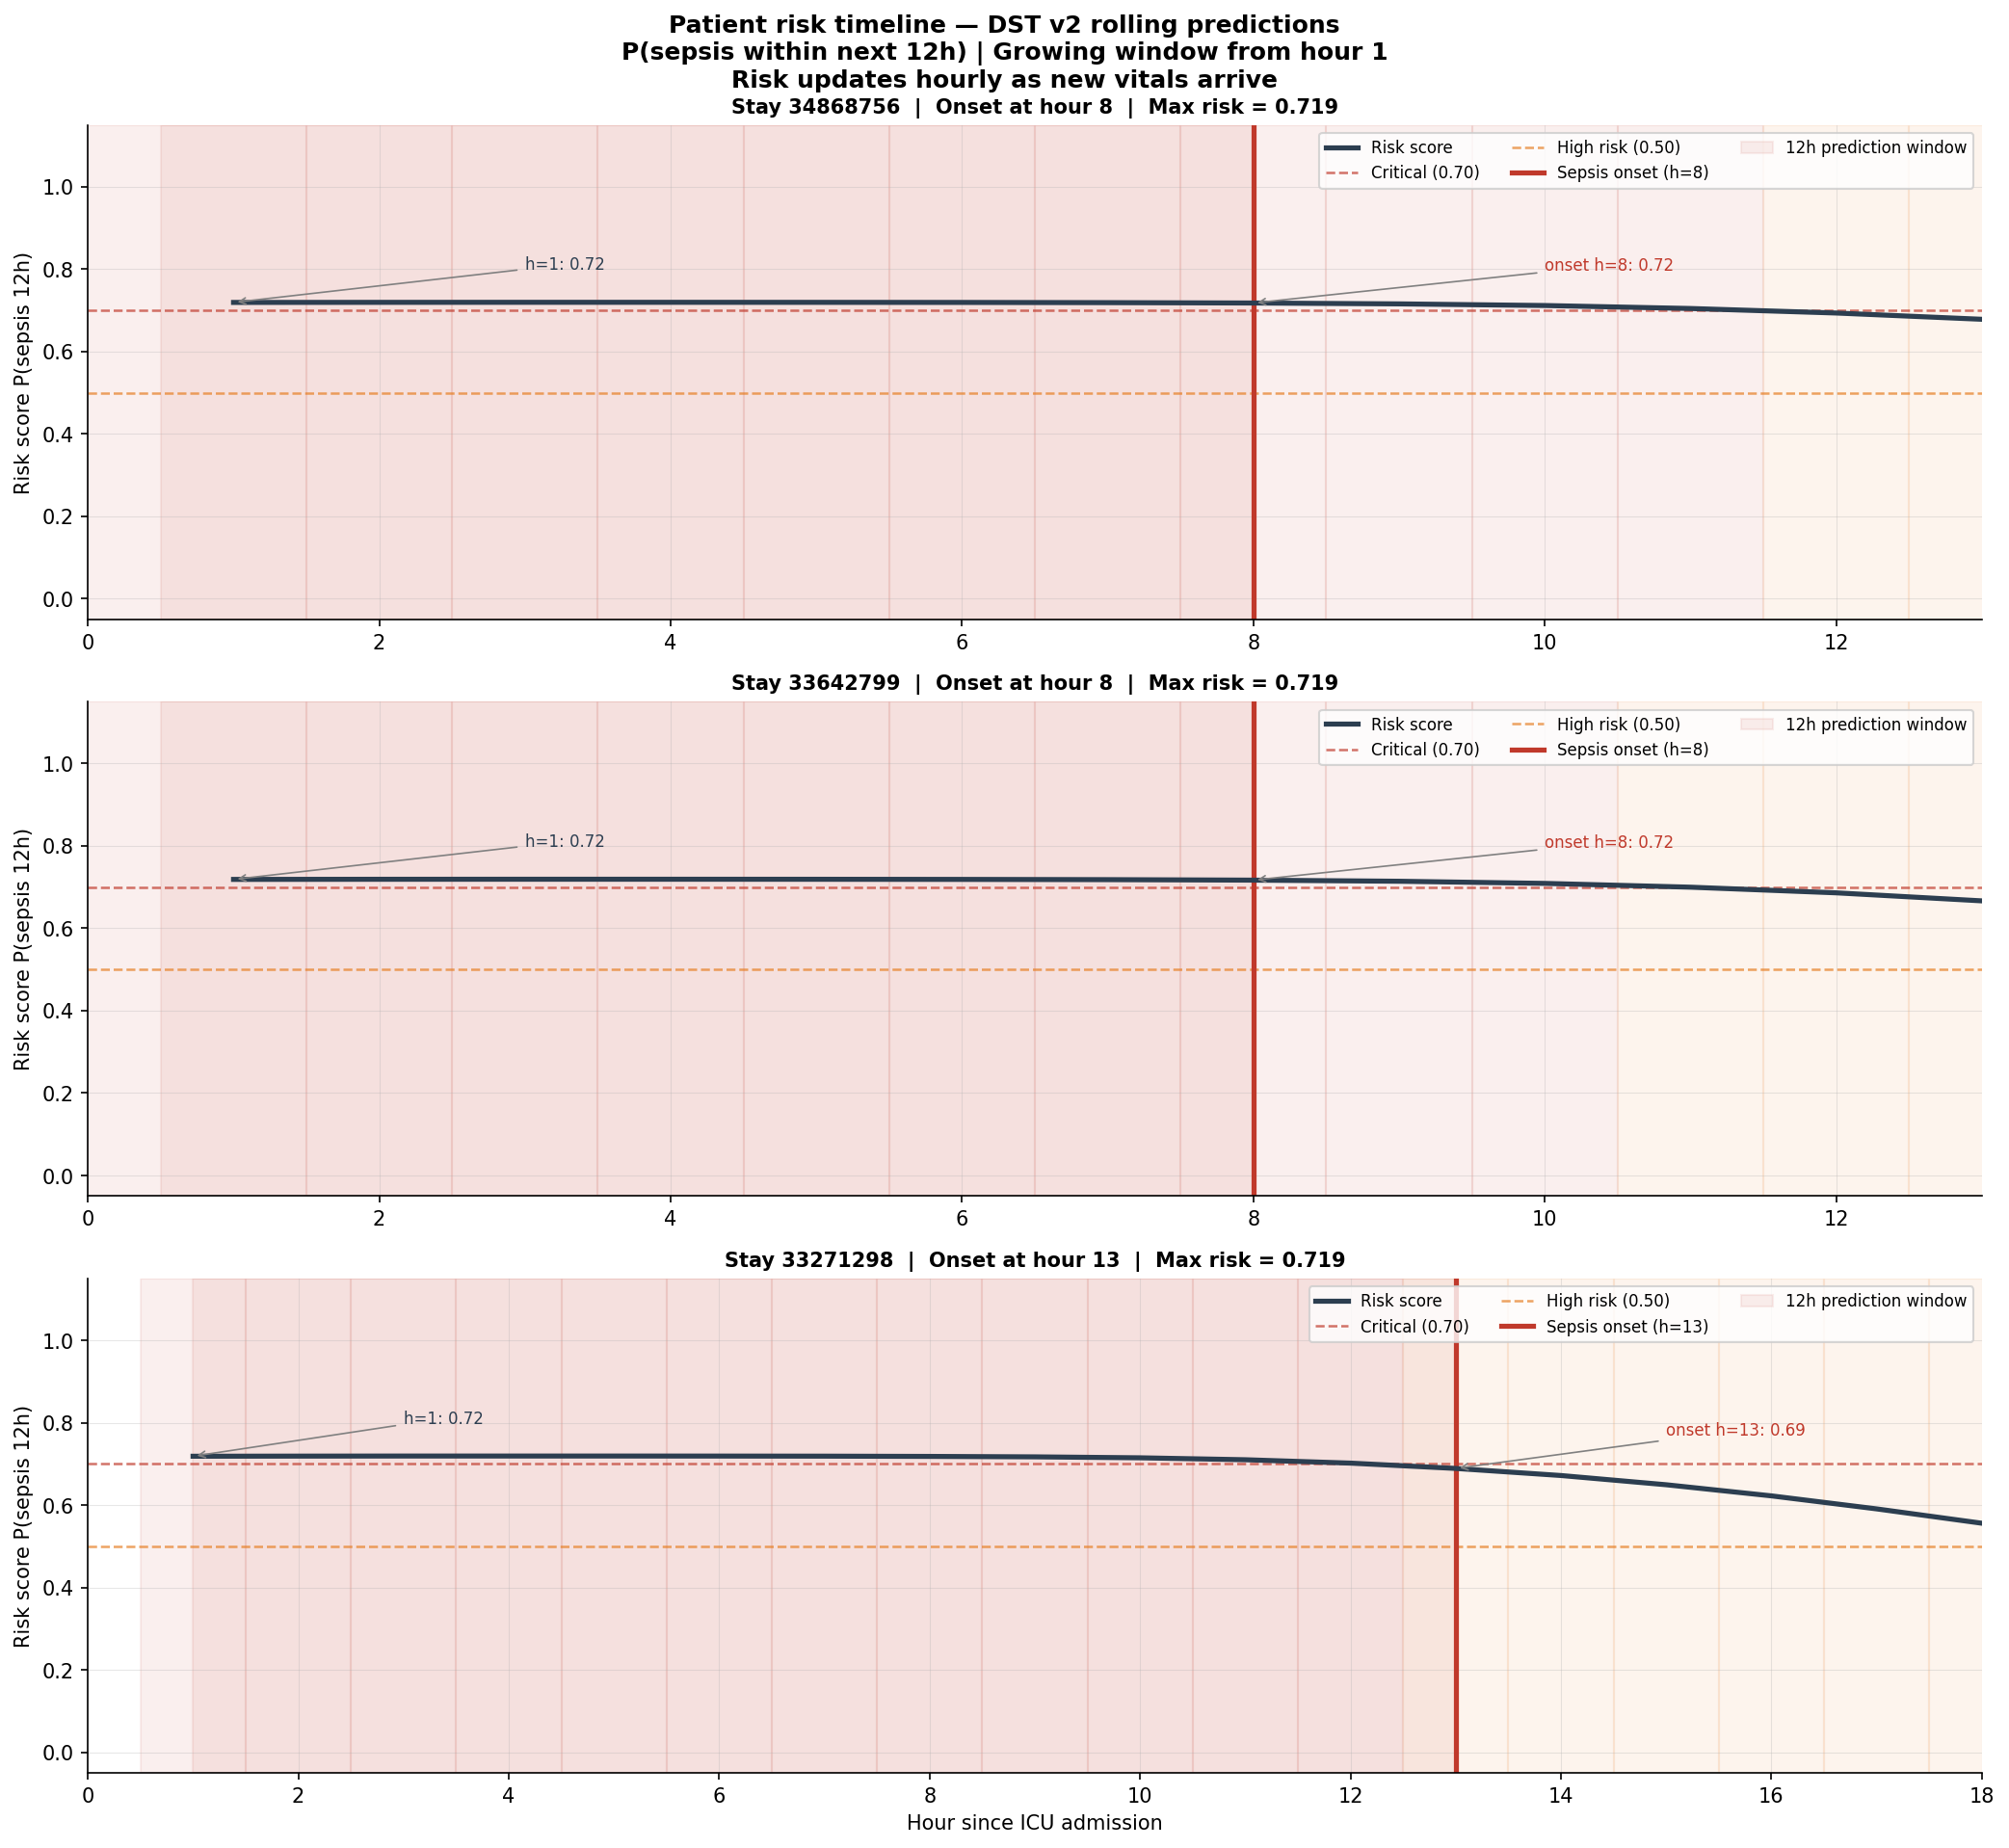

Saved -> fig7_patient_timelines.png ✓


In [25]:
# ── Patient timeline visualization — DST v2 ───────────────────
print('Building patient timeline figure...')

test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)].copy()

tier_colors_map = {
    'no_alert' : '#27AE60',
    'high_risk': '#E67E22',
    'critical' : '#C0392B',
}

# ── Find best examples of real DST v2 behavior ────────────────
candidate_patients = []
for sid in test_inc['stay_id'].unique():
    onset = onset_lookup.get(sid)
    if onset is None or onset < 8 or onset > 80:
        continue
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')
    if len(stay) < onset:
        continue
    pre6  = stay[stay['hour'].between(max(1, onset-6), onset)]['risk_score']
    pre_onset = stay[stay['hour'] <= onset]['risk_score']
    if len(pre6) == 0 or pre6.max() < 0.15:
        continue
    if pre_onset.max() < 0.30:
        continue
    quality = pre6.max() + pre_onset.max()
    candidate_patients.append((sid, onset, quality))

candidate_patients = sorted(candidate_patients, key=lambda x: x[2], reverse=True)
sample_patients    = [(x[0], x[1]) for x in candidate_patients[:3]]
print(f'Found {len(candidate_patients)} candidates')
for sid, onset in sample_patients:
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')
    print(f'  stay={sid}  onset={onset}h  max_risk={stay["risk_score"].max():.3f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
fig.suptitle(
    'Patient risk timeline — DST v2 rolling predictions\n'
    'P(sepsis within next 12h) | Growing window from hour 1\n'
    'Risk updates hourly as new vitals arrive',
    fontsize=12, fontweight='bold'
)

for ax, (sid, onset) in zip(axes, sample_patients):
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')

    for _, row in stay.iterrows():
        ax.axvspan(row['hour'] - 0.5, row['hour'] + 0.5,
                   alpha=0.08,
                   color=tier_colors_map.get(row['alert_tier'], 'gray'))

    ax.plot(stay['hour'], stay['risk_score'],
            color='#2C3E50', lw=2.5, zorder=3, label='Risk score')
    ax.axhline(0.70, color='#C0392B', lw=1.2, ls='--',
               alpha=0.7, label='Critical (0.70)')
    ax.axhline(0.50, color='#E67E22', lw=1.2, ls='--',
               alpha=0.7, label='High risk (0.50)')
    ax.axvline(onset, color='#C0392B', lw=2.5,
               label=f'Sepsis onset (h={onset})')
    ax.axvspan(max(0, onset-12), onset, alpha=0.08,
               color='#C0392B', label='12h prediction window')

    risk_h1    = stay[stay['hour'] == 1]['risk_score'].values
    risk_onset = stay[stay['hour'] == onset]['risk_score'].values
    if len(risk_h1) > 0:
        ax.annotate(f'h=1: {risk_h1[0]:.2f}',
                    xy=(1, risk_h1[0]),
                    xytext=(3, min(risk_h1[0]+0.08, 1.0)),
                    fontsize=8, color='#2C3E50',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    if len(risk_onset) > 0:
        ax.annotate(f'onset h={onset}: {risk_onset[0]:.2f}',
                    xy=(onset, risk_onset[0]),
                    xytext=(onset+2, min(risk_onset[0]+0.08, 1.0)),
                    fontsize=8, color='#C0392B',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    x_min = 0
    x_max = min(stay['hour'].max(), onset + 12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel('Risk score P(sepsis 12h)')
    ax.set_title(
        f'Stay {sid}  |  Onset at hour {onset}  |  '
        f'Max risk = {stay["risk_score"].max():.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right', ncol=3)

axes[-1].set_xlabel('Hour since ICU admission')
plt.tight_layout()
fpath = FIG_DIR / 'fig7_patient_timelines.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

Building DST v2 patient timelines...
Found 108 candidates
  stay=33271298  onset=13h  max_risk=0.719  risk@onset=[0.6891]
  stay=36342317  onset=12h  max_risk=0.718  risk@onset=[0.6747]
  stay=37272903  onset=13h  max_risk=0.719  risk@onset=[0.6736]


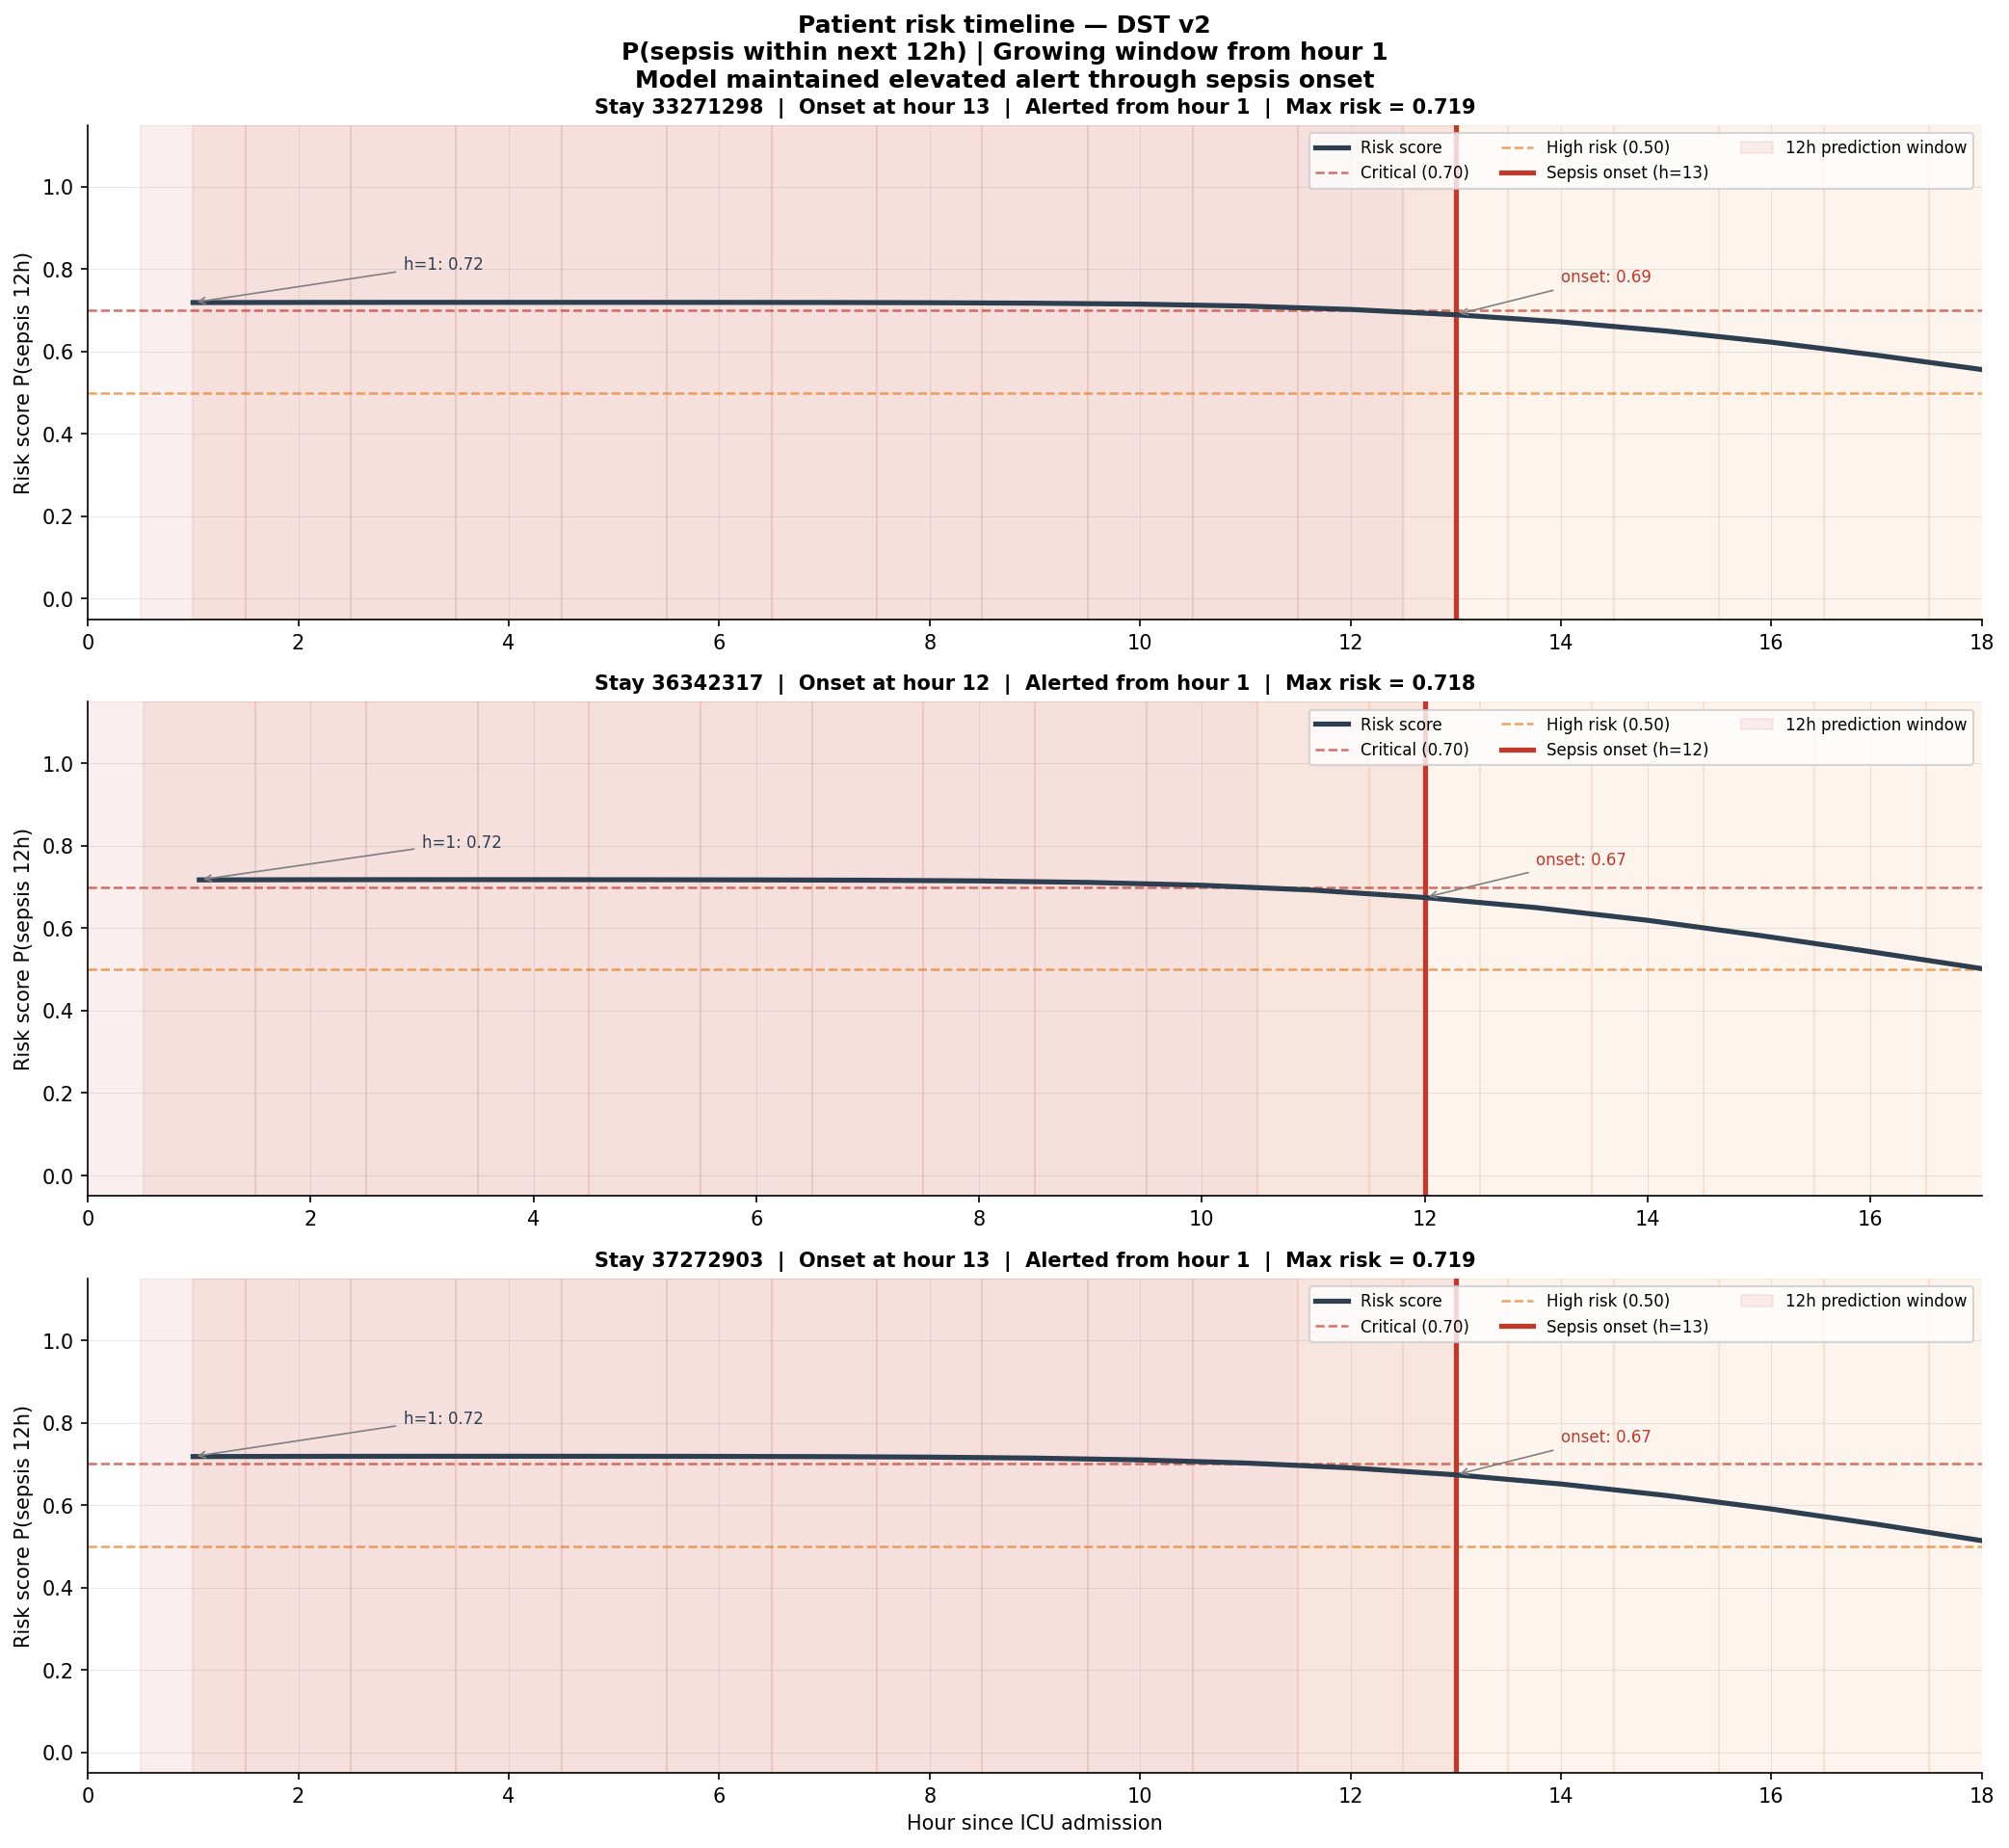

Saved -> fig7_patient_timelines2.png ✓


In [27]:
# ── Patient timeline — DST v2 ─────────────────────────────────
print('Building DST v2 patient timelines...')

test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)].copy()

tier_colors_map = {
    'no_alert' : '#27AE60',
    'high_risk': '#E67E22',
    'critical' : '#C0392B',
}

# Find patients where risk stays elevated through onset
good_patients = []
for sid in test_inc['stay_id'].unique():
    onset = onset_lookup.get(sid)
    if onset is None or onset < 12 or onset > 80:
        continue
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')
    if len(stay) < onset:
        continue
    pre6      = stay[stay['hour'].between(max(1, onset-6), onset)]['risk_score']
    pre_onset = stay[stay['hour'] <= onset]['risk_score']
    if len(pre6) == 0 or pre6.mean() < 0.30:
        continue
    if pre_onset.max() < 0.40:
        continue
    good_patients.append((sid, onset, pre6.mean()))

good_patients  = sorted(good_patients, key=lambda x: x[2], reverse=True)
sample_patients = [(x[0], x[1]) for x in good_patients[:3]]
print(f'Found {len(good_patients)} candidates')
for sid, onset in sample_patients:
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')
    print(f'  stay={sid}  onset={onset}h  '
          f'max_risk={stay["risk_score"].max():.3f}  '
          f'risk@onset={stay[stay["hour"]==onset]["risk_score"].values}')

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
fig.suptitle(
    'Patient risk timeline — DST v2\n'
    'P(sepsis within next 12h) | Growing window from hour 1\n'
    'Model maintained elevated alert through sepsis onset',
    fontsize=12, fontweight='bold'
)

for ax, (sid, onset) in zip(axes, sample_patients):
    stay = test_inc[test_inc['stay_id'] == sid].sort_values('hour')

    for _, row in stay.iterrows():
        ax.axvspan(row['hour'] - 0.5, row['hour'] + 0.5,
                   alpha=0.08,
                   color=tier_colors_map.get(row['alert_tier'], 'gray'))

    ax.plot(stay['hour'], stay['risk_score'],
            color='#2C3E50', lw=2.5, zorder=3, label='Risk score')
    ax.axhline(0.70, color='#C0392B', lw=1.2, ls='--',
               alpha=0.7, label='Critical (0.70)')
    ax.axhline(0.50, color='#E67E22', lw=1.2, ls='--',
               alpha=0.7, label='High risk (0.50)')
    ax.axvline(onset, color='#C0392B', lw=2.5,
               label=f'Sepsis onset (h={onset})')
    ax.axvspan(max(0, onset-12), onset, alpha=0.08,
               color='#C0392B', label='12h prediction window')

    risk_h1    = stay[stay['hour'] == 1]['risk_score'].values
    risk_onset = stay[stay['hour'] == onset]['risk_score'].values
    if len(risk_h1) > 0:
        ax.annotate(f'h=1: {risk_h1[0]:.2f}',
                    xy=(1, risk_h1[0]),
                    xytext=(3, min(risk_h1[0]+0.08, 1.05)),
                    fontsize=8, color='#2C3E50',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    if len(risk_onset) > 0:
        ax.annotate(f'onset: {risk_onset[0]:.2f}',
                    xy=(onset, risk_onset[0]),
                    xytext=(onset+1, min(risk_onset[0]+0.08, 1.05)),
                    fontsize=8, color='#C0392B',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    x_min = 0
    x_max = min(stay['hour'].max(), onset + 12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel('Risk score P(sepsis 12h)')
    ax.set_title(
        f'Stay {sid}  |  Onset at hour {onset}  |  '
        f'Alerted from hour 1  |  '
        f'Max risk = {stay["risk_score"].max():.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right', ncol=3)

axes[-1].set_xlabel('Hour since ICU admission')
plt.tight_layout()
fpath = FIG_DIR / 'fig7_patient_timelines2.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

Finding no-sepsis patients with clear risk decrease...
Found 3721 candidates

Top 5:
  stay=38518590  early=0.707  late=0.019  drop=0.688  stay_length=199h
  stay=36094197  early=0.712  late=0.024  drop=0.688  stay_length=199h
  stay=31567795  early=0.704  late=0.017  drop=0.687  stay_length=199h
  stay=30234210  early=0.713  late=0.027  drop=0.687  stay_length=188h
  stay=35222536  early=0.707  late=0.020  drop=0.687  stay_length=199h


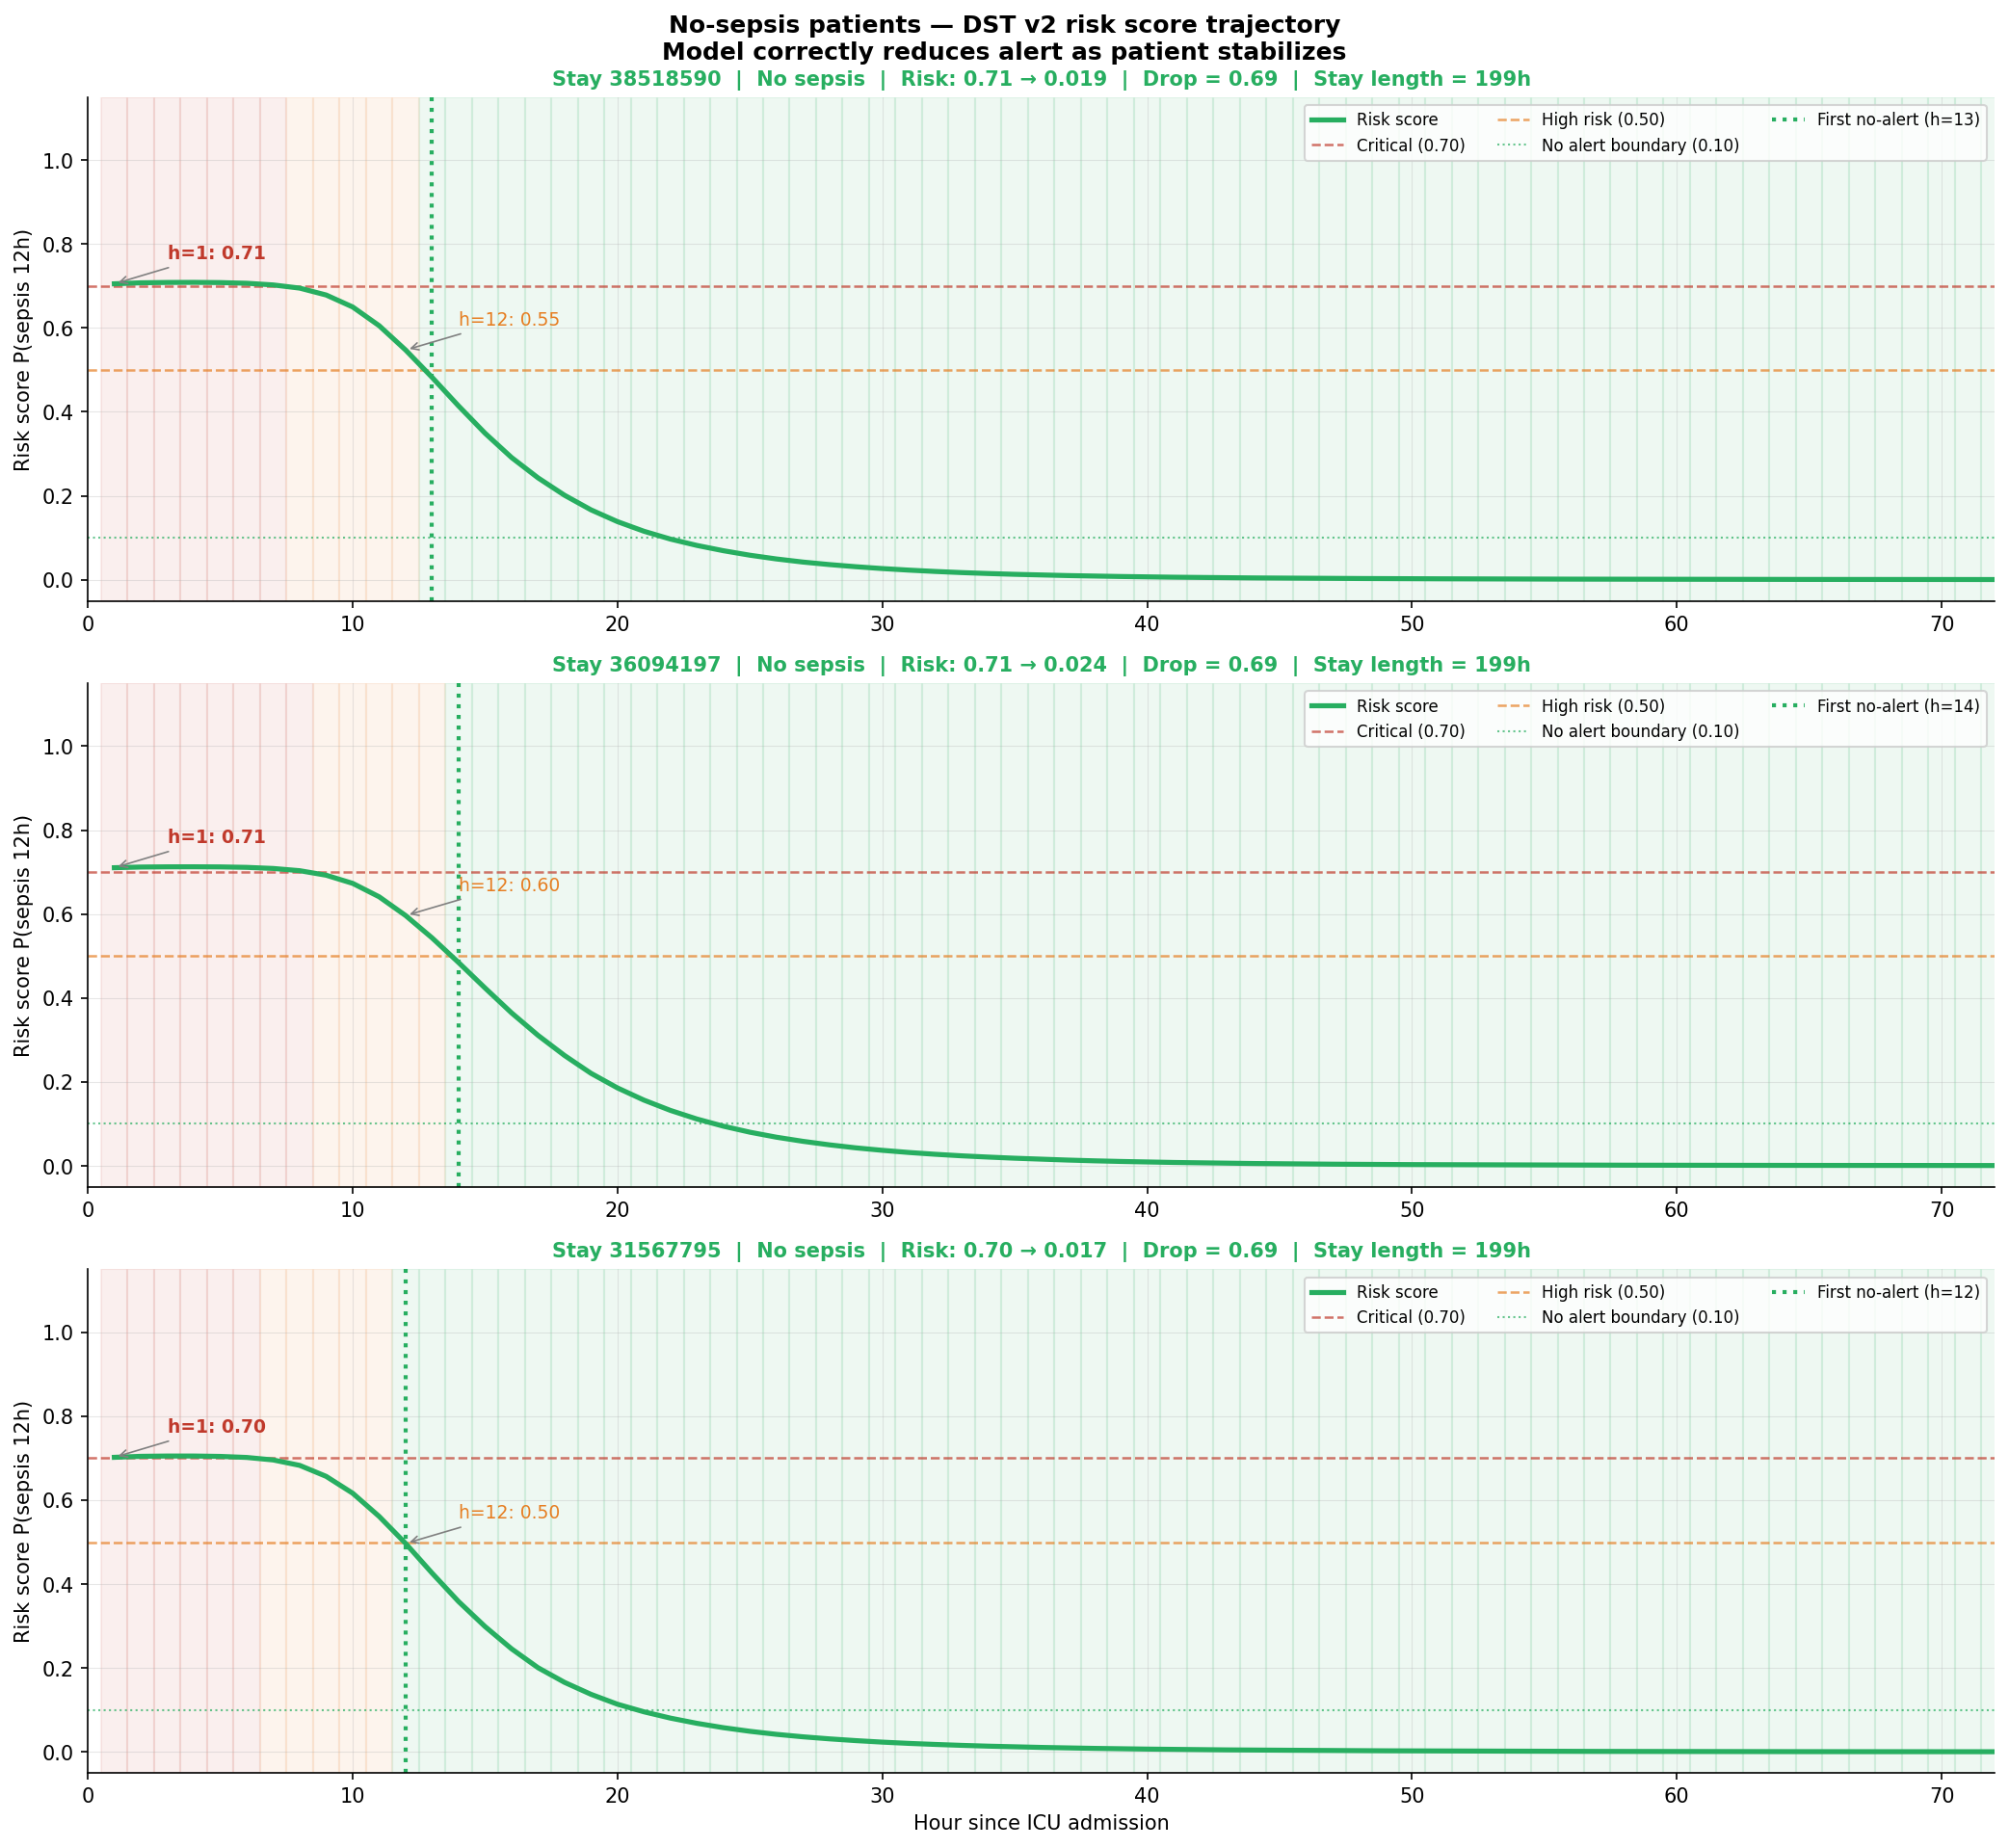

Saved -> fig_no_sepsis_trajectories.png ✓


In [30]:
# ── Find best no-sepsis patients with clear risk decrease ──────
print("Finding no-sepsis patients with clear risk decrease...")

no_sepsis_test = test_inc[
    ~test_inc['stay_id'].isin(set(onset_lookup.keys()))
].copy()

candidates = []
for sid in no_sepsis_test['stay_id'].unique():
    stay = no_sepsis_test[no_sepsis_test['stay_id'] == sid].sort_values('hour')
    if len(stay) < 12:
        continue

    early = stay[stay['hour'] <= 3]['risk_score']
    late  = stay[stay['hour'] >= 12]['risk_score']

    if len(early) == 0 or len(late) == 0:
        continue

    # Starts high, ends low
    if early.mean() < 0.30:
        continue
    if late.mean() > 0.10:
        continue

    drop    = early.mean() - late.mean()
    max_hrs = stay['hour'].max()
    candidates.append((sid, early.mean(), late.mean(), drop, max_hrs))

candidates = sorted(candidates, key=lambda x: x[3], reverse=True)
print(f'Found {len(candidates)} candidates')
print(f'\nTop 5:')
for sid, e, l, drop, max_h in candidates[:5]:
    print(f'  stay={sid}  early={e:.3f}  late={l:.3f}  '
          f'drop={drop:.3f}  stay_length={max_h}h')

# ── Plot top 3 ────────────────────────────────────────────────
if len(candidates) >= 3:
    fig, axes = plt.subplots(3, 1, figsize=(14, 13))
    fig.suptitle(
        'No-sepsis patients — DST v2 risk score trajectory\n'
        'Model correctly reduces alert as patient stabilizes',
        fontsize=12, fontweight='bold'
    )

    for ax, (sid, early_mean, late_mean, drop, max_h) in zip(axes, candidates[:3]):
        stay = no_sepsis_test[no_sepsis_test['stay_id'] == sid].sort_values('hour')

        # Background shading
        for _, row in stay.iterrows():
            ax.axvspan(row['hour'] - 0.5, row['hour'] + 0.5,
                       alpha=0.08,
                       color=tier_colors_map.get(row['alert_tier'], 'gray'))

        # Risk line
        ax.plot(stay['hour'], stay['risk_score'],
                color='#27AE60', lw=2.5, zorder=3, label='Risk score')

        # Thresholds
        ax.axhline(0.70, color='#C0392B', lw=1.2, ls='--',
                   alpha=0.7, label='Critical (0.70)')
        ax.axhline(0.50, color='#E67E22', lw=1.2, ls='--',
                   alpha=0.7, label='High risk (0.50)')
        ax.axhline(0.10, color='#27AE60', lw=1.0, ls=':',
                   alpha=0.7, label='No alert boundary (0.10)')

        # Annotate key points
        risk_h1   = stay[stay['hour'] == 1]['risk_score'].values
        risk_h12  = stay[stay['hour'] == 12]['risk_score'].values
        risk_last = stay.iloc[-1]['risk_score']
        last_hour = stay.iloc[-1]['hour']

        if len(risk_h1) > 0:
            ax.annotate(f'h=1: {risk_h1[0]:.2f}',
                        xy=(1, risk_h1[0]),
                        xytext=(3, min(risk_h1[0]+0.06, 1.05)),
                        fontsize=9, color='#C0392B', fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
        if len(risk_h12) > 0:
            ax.annotate(f'h=12: {risk_h12[0]:.2f}',
                        xy=(12, risk_h12[0]),
                        xytext=(14, risk_h12[0]+0.06),
                        fontsize=9, color='#E67E22',
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
        ax.annotate(f'h={last_hour}: {risk_last:.2f}',
                    xy=(last_hour, risk_last),
                    xytext=(max(last_hour-10, 1), risk_last+0.06),
                    fontsize=9, color='#27AE60', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

        # Shade the "clearing" zone
        cleared = stay[stay['alert_tier'] == 'no_alert']
        if len(cleared) > 0:
            first_clear = cleared['hour'].min()
            ax.axvline(first_clear, color='#27AE60', lw=2, ls=':',
                       label=f'First no-alert (h={first_clear})')

        x_max = min(stay['hour'].max(), 72)
        ax.set_xlim(0, x_max)
        ax.set_ylim(-0.05, 1.15)
        ax.set_ylabel('Risk score P(sepsis 12h)')
        ax.set_title(
            f'Stay {sid}  |  No sepsis  |  '
            f'Risk: {early_mean:.2f} → {late_mean:.3f}  |  '
            f'Drop = {drop:.2f}  |  Stay length = {max_h}h',
            fontsize=10, fontweight='bold', color='#27AE60'
        )
        ax.legend(fontsize=8, loc='upper right', ncol=3)

    axes[-1].set_xlabel('Hour since ICU admission')
    plt.tight_layout()
    fpath = FIG_DIR / 'fig_no_sepsis_trajectories.png'
    plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {fpath.name} ✓')
else:
    print('Not enough candidates found')

In [32]:
# Already saved as fig_no_sepsis_trajectories.png
# Copy to fig15
import shutil
shutil.copy(
    str(FIG_DIR / 'fig_no_sepsis_trajectories.png'),
    str(FIG_DIR / 'fig15_no_sepsis_trajectories.png')
)
print('Saved -> fig15_no_sepsis_trajectories.png ✓')

Saved -> fig15_no_sepsis_trajectories.png ✓


Building DST v2 SHAP figures...
  dst_shap_values shape : (500, 127)
  feature_cols          : 127


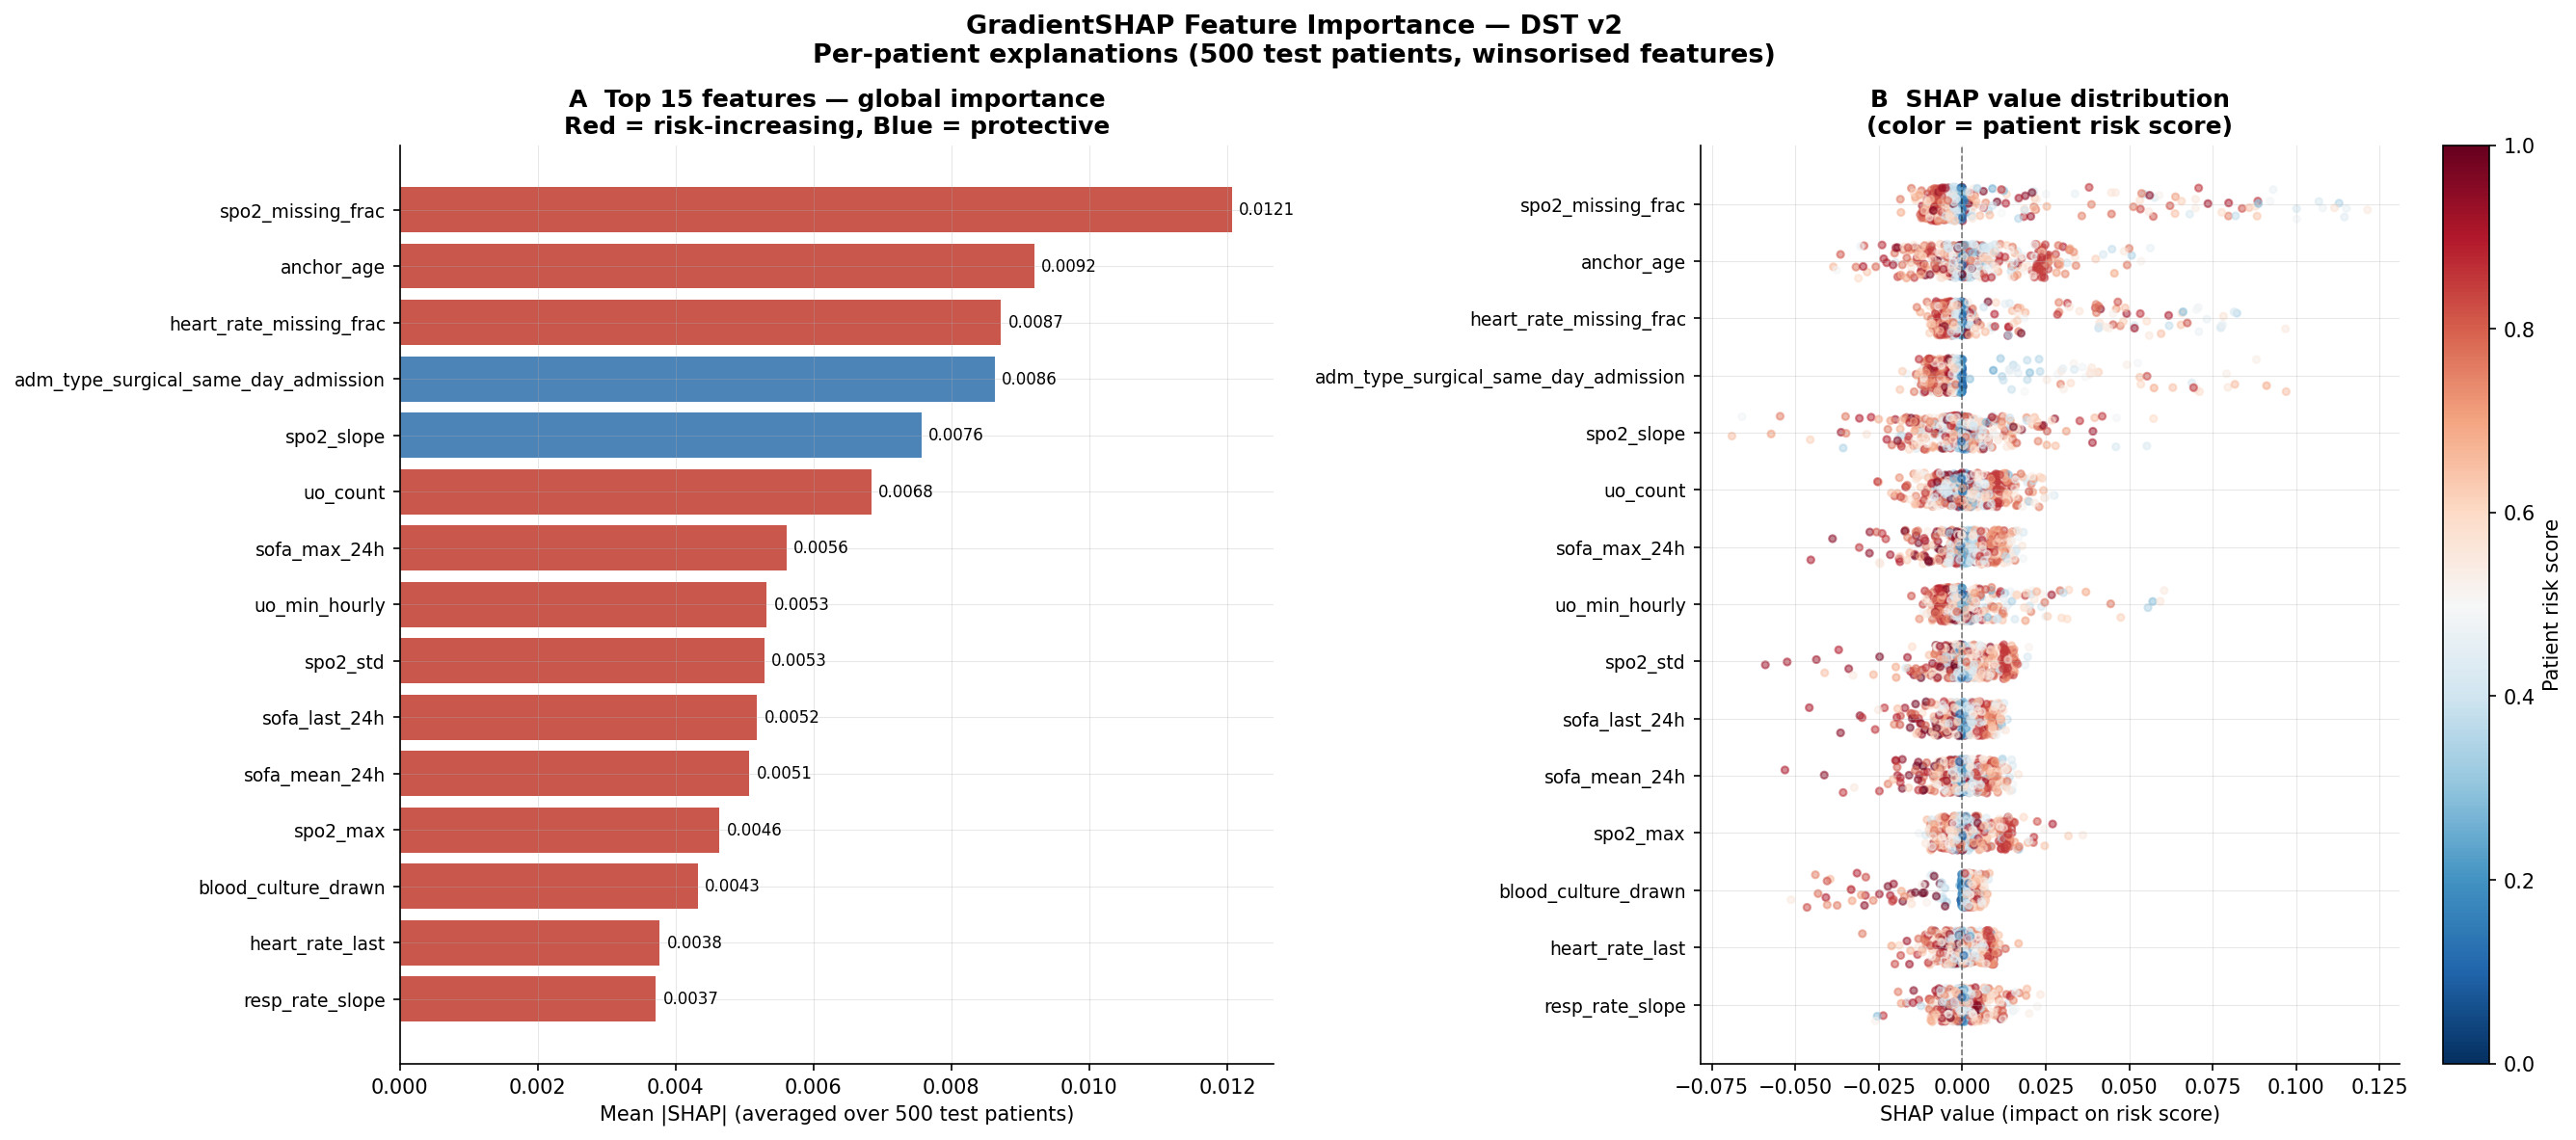

Saved -> fig8_dst_shap_importance.png ✓


In [33]:
# ── Cell 5a: DST v2 GradientSHAP — Global Feature Importance ──
print('Building DST v2 SHAP figures...')
print(f'  dst_shap_values shape : {dst_shap_values.shape}')
print(f'  feature_cols          : {len(feature_cols)}')

mean_abs_shap = np.abs(dst_shap_values).mean(axis=0)
signed_shap   = dst_shap_values.mean(axis=0)
top15_idx     = np.argsort(mean_abs_shap)[::-1][:15]
top15_names   = [feature_cols[i] for i in top15_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'GradientSHAP Feature Importance — DST v2\n'
    'Per-patient explanations (500 test patients, winsorised features)',
    fontsize=13, fontweight='bold'
)

# ── Panel A: Bar chart ────────────────────────────────────────
colors_bar = ['#C0392B' if signed_shap[i] > 0 else '#2C6FAC'
              for i in top15_idx[::-1]]
bars = axes[0].barh(range(15), mean_abs_shap[top15_idx][::-1],
                    color=colors_bar, alpha=0.85)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top15_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP| (averaged over 500 test patients)')
axes[0].set_title('A  Top 15 features — global importance\n'
                  'Red = risk-increasing, Blue = protective',
                  fontweight='bold')
for bar, val in zip(bars, mean_abs_shap[top15_idx][::-1]):
    axes[0].text(val + 0.0001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# ── Panel B: Beeswarm-style dot plot ─────────────────────────
for rank, fi in enumerate(top15_idx):
    shap_vals_feat = dst_shap_values[:, fi]
    y_pos          = 14 - rank
    feat_vals      = dst_shap_meta['risk_score'].values
    norm_vals      = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-9)
    axes[1].scatter(
        shap_vals_feat,
        np.full_like(shap_vals_feat, y_pos) +
        np.random.uniform(-0.3, 0.3, len(shap_vals_feat)),
        c=norm_vals, cmap='RdBu_r', alpha=0.5, s=12
    )

axes[1].axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15_names[::-1], fontsize=9)
axes[1].set_xlabel('SHAP value (impact on risk score)')
axes[1].set_title('B  SHAP value distribution\n(color = patient risk score)',
                  fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdBu_r',
                            norm=plt.Normalize(vmin=0, vmax=1))
plt.colorbar(sm, ax=axes[1], label='Patient risk score')

plt.tight_layout()
fpath = FIG_DIR / 'fig8_dst_shap_importance.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

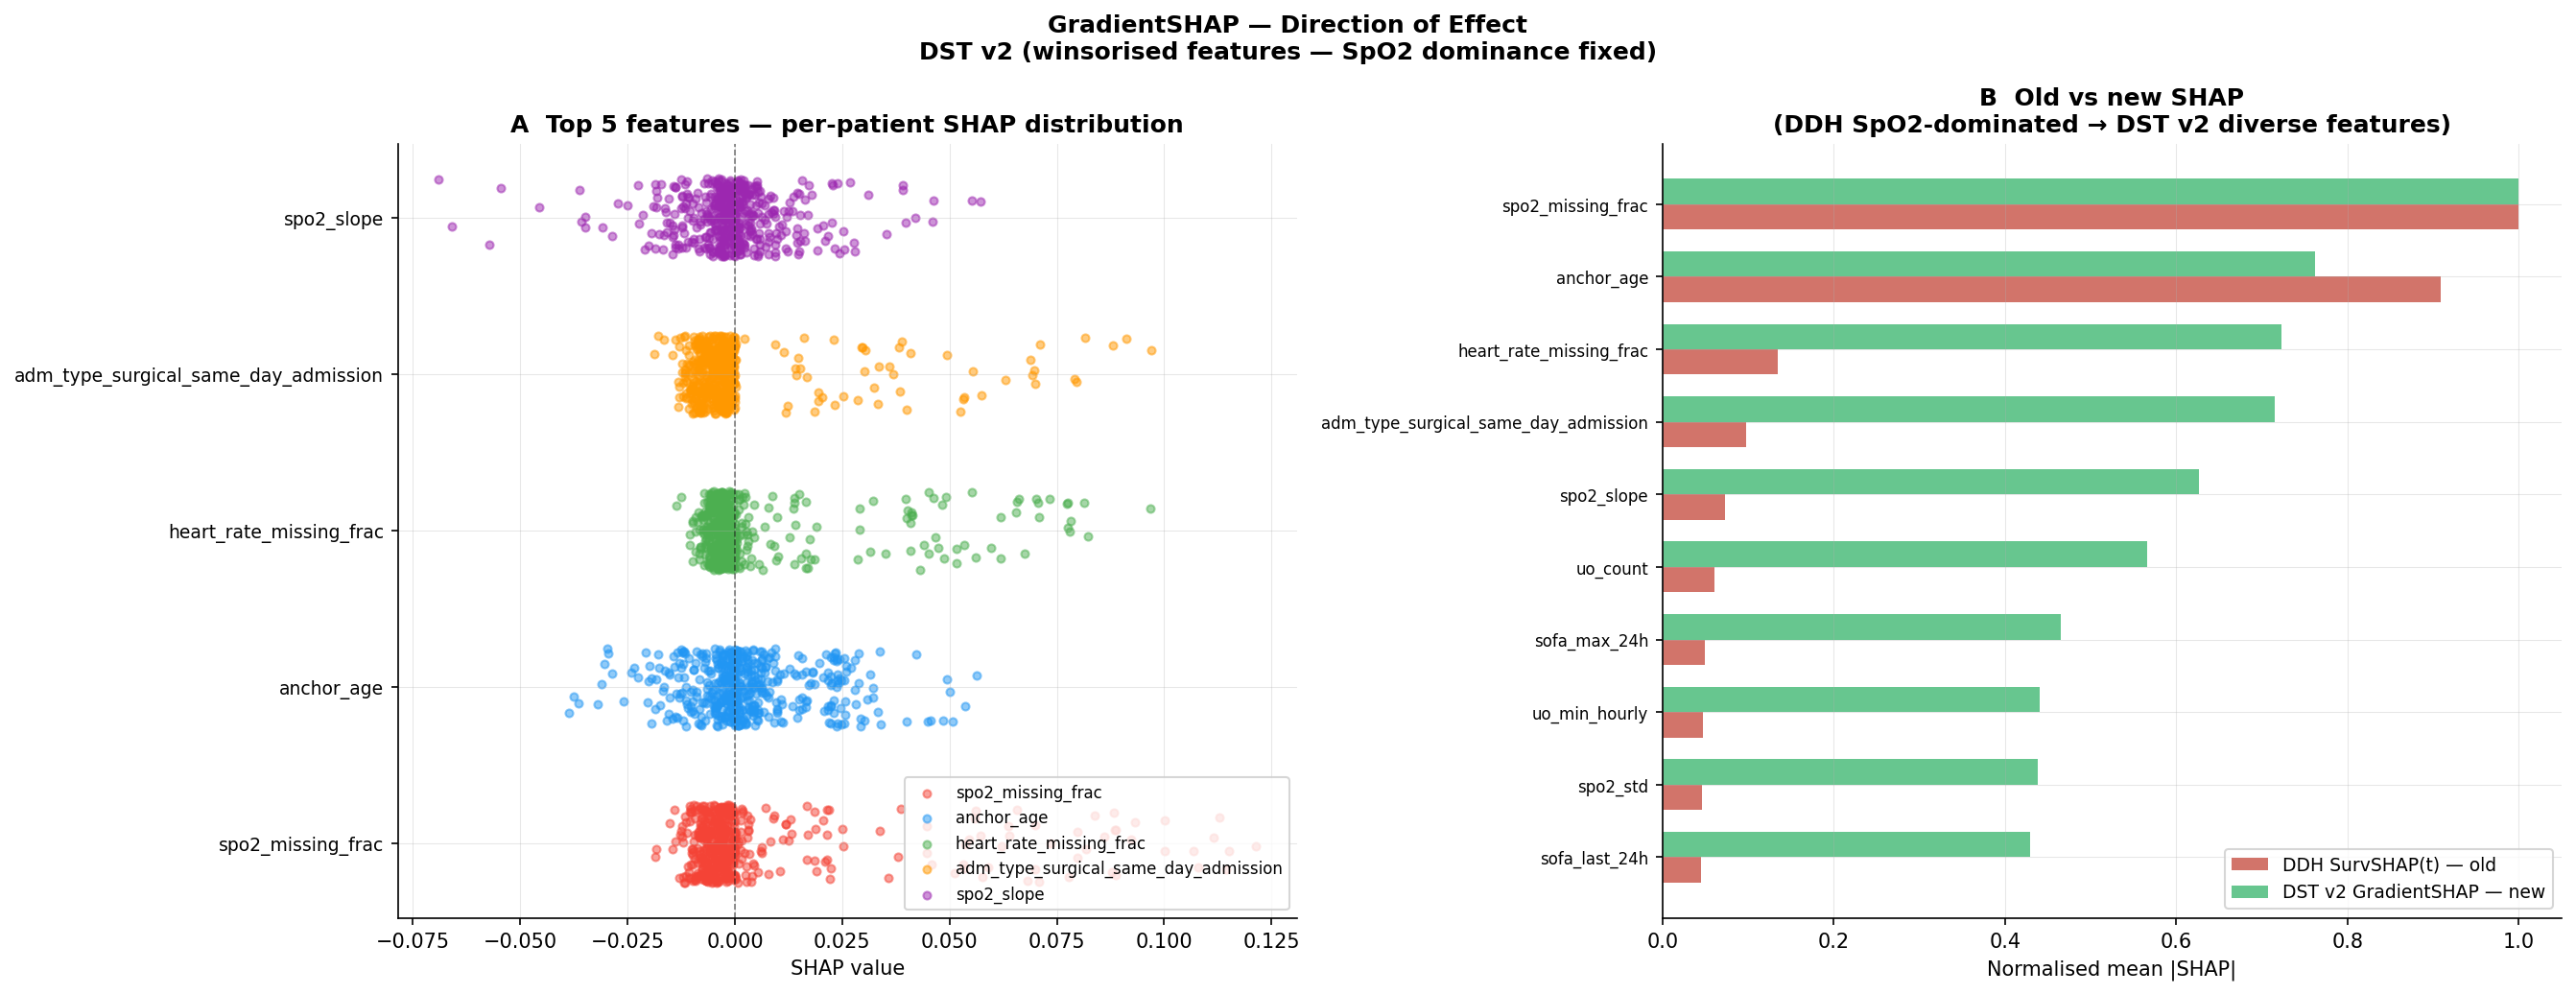

Saved -> fig9_dst_shap_direction.png ✓

Top 10 features — DST v2 GradientSHAP:
 Rank Feature                              Mean |SHAP|  Direction
-----------------------------------------------------------------
    1 spo2_missing_frac                        0.01207     Risk +
    2 anchor_age                               0.00920     Risk +
    3 heart_rate_missing_frac                  0.00872     Risk +
    4 adm_type_surgical_same_day_admission      0.00863 Protective
    5 spo2_slope                               0.00757 Protective
    6 uo_count                                 0.00684     Risk +
    7 sofa_max_24h                             0.00561     Risk +
    8 uo_min_hourly                            0.00532     Risk +
    9 spo2_std                                 0.00529     Risk +
   10 sofa_last_24h                            0.00518     Risk +

Section 5 complete ✓


In [34]:
# ── Cell 5b: DST v2 SHAP — Direction of effect ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'GradientSHAP — Direction of Effect\n'
    'DST v2 (winsorised features — SpO2 dominance fixed)',
    fontsize=12, fontweight='bold'
)

top5_idx   = top15_idx[:5]
top5_names = [feature_cols[i] for i in top5_idx]
palette    = ['#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ── Panel A: Per-feature SHAP distributions ───────────────────
ax = axes[0]
for rank, (fi, clr) in enumerate(zip(top5_idx, palette)):
    vals = dst_shap_values[:, fi]
    ax.scatter(
        vals,
        np.full_like(vals, rank) + np.random.uniform(-0.25, 0.25, len(vals)),
        color=clr, alpha=0.5, s=15, label=feature_cols[fi]
    )
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_yticks(range(5))
ax.set_yticklabels(top5_names, fontsize=9)
ax.set_xlabel('SHAP value')
ax.set_title('A  Top 5 features — per-patient SHAP distribution',
             fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# ── Panel B: Old DDH vs New DST comparison ────────────────────
ax = axes[1]
old_mabs  = np.abs(shap_values).mean(axis=(0, 2))
old_top10 = np.argsort(old_mabs)[::-1][:10]
old_names = [feature_cols[i] for i in old_top10]
old_vals  = old_mabs[old_top10]

new_top10 = np.argsort(mean_abs_shap)[::-1][:10]
new_names = [feature_cols[i] for i in new_top10]
new_vals  = mean_abs_shap[new_top10]

x = np.arange(10)
w = 0.35
ax.barh(x - w/2, old_vals[::-1] / old_vals.max(),
        w, color='#C0392B', alpha=0.7, label='DDH SurvSHAP(t) — old')
ax.barh(x + w/2, new_vals[::-1] / new_vals.max(),
        w, color='#27AE60', alpha=0.7, label='DST v2 GradientSHAP — new')
ax.set_yticks(x)
ax.set_yticklabels(new_names[::-1], fontsize=8)
ax.set_xlabel('Normalised mean |SHAP|')
ax.set_title('B  Old vs new SHAP\n'
             '(DDH SpO2-dominated → DST v2 diverse features)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
fpath = FIG_DIR / 'fig9_dst_shap_direction.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

# ── Print top 10 summary ──────────────────────────────────────
print(f'\nTop 10 features — DST v2 GradientSHAP:')
print(f"{'Rank':>5} {'Feature':<35} {'Mean |SHAP|':>12} {'Direction':>10}")
print('-' * 65)
signed_dst = dst_shap_values.mean(axis=0)
for rank, fi in enumerate(new_top10, 1):
    direction = 'Risk +' if signed_dst[fi] > 0 else 'Protective'
    print(f'{rank:>5} {feature_cols[fi]:<35} '
          f'{mean_abs_shap[fi]:>12.5f} {direction:>10}')

print('\nSection 5 complete ✓')

Building final summary figure...


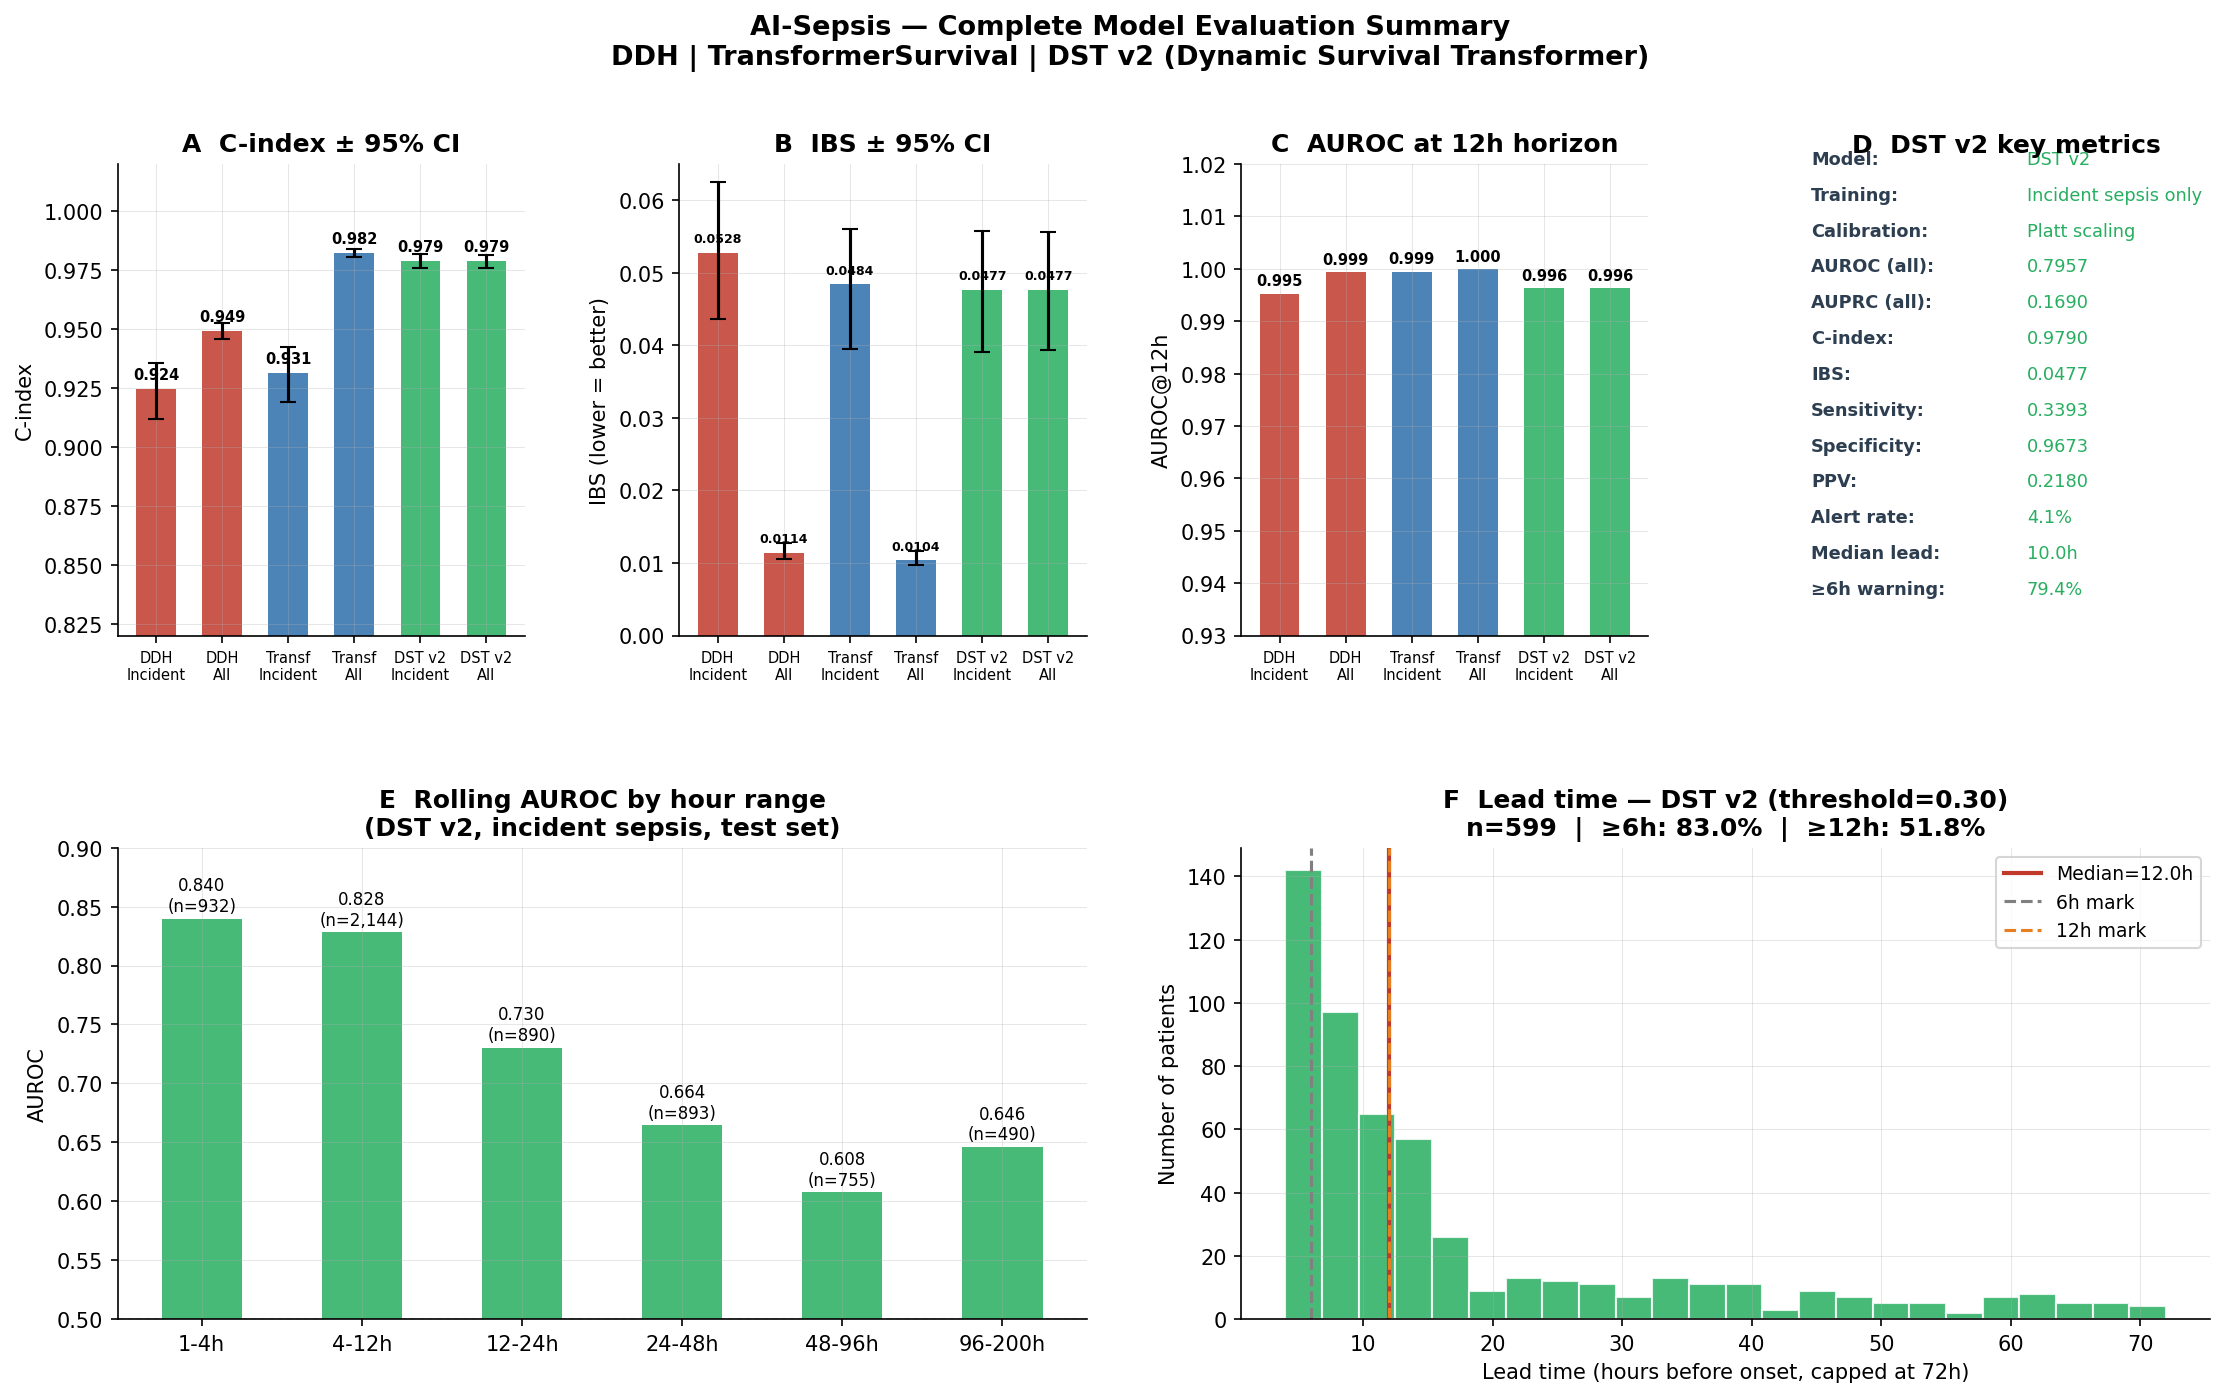

Saved -> fig11_final_summary.png ✓

04 Section 6 complete ✓


In [35]:
# ── Cell 6b: Final summary figure — DST v2 ───────────────────
print('Building final summary figure...')

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle(
    'AI-Sepsis — Complete Model Evaluation Summary\n'
    'DDH | TransformerSurvival | DST v2 (Dynamic Survival Transformer)',
    fontsize=13, fontweight='bold'
)

# ── Panel A: C-index comparison ───────────────────────────────
ax = fig.add_subplot(gs[0, 0])
model_labels = ['DDH\nIncident', 'DDH\nAll',
                'Transf\nIncident', 'Transf\nAll',
                'DST v2\nIncident', 'DST v2\nAll']
ci_vals  = bootstrap_df['C-index'].values
ci_lo    = bootstrap_df['CI_lo'].values
ci_hi    = bootstrap_df['CI_hi'].values
colors_b = ['#C0392B','#C0392B','#2C6FAC','#2C6FAC','#27AE60','#27AE60']
x        = np.arange(len(model_labels))
bars     = ax.bar(x, ci_vals, color=colors_b, alpha=0.85, width=0.6)
ax.errorbar(x, ci_vals,
            yerr=[ci_vals-ci_lo, ci_hi-ci_vals],
            fmt='none', color='black', capsize=4, lw=1.5)
for bar, v in zip(bars, ci_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=7)
ax.set_ylim(0.82, 1.02)
ax.set_ylabel('C-index')
ax.set_title('A  C-index ± 95% CI', fontweight='bold')

# ── Panel B: IBS comparison ───────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ibs_vals = bootstrap_df['IBS'].values
ibs_lo   = bootstrap_df['IBS_lo'].values
ibs_hi   = bootstrap_df['IBS_hi'].values
bars     = ax.bar(x, ibs_vals, color=colors_b, alpha=0.85, width=0.6)
ax.errorbar(x, ibs_vals,
            yerr=[ibs_vals-ibs_lo, ibs_hi-ibs_vals],
            fmt='none', color='black', capsize=4, lw=1.5)
for bar, v in zip(bars, ibs_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=6, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=7)
ax.set_ylim(0, 0.065)
ax.set_ylabel('IBS (lower = better)')
ax.set_title('B  IBS ± 95% CI', fontweight='bold')

# ── Panel C: AUROC at 12h horizon ────────────────────────────
ax = fig.add_subplot(gs[0, 2])
bin_12 = int(np.clip(np.searchsorted(time_cuts, 12, 'right'), 0, NUM_BINS-1))
auroc_12 = []
for surv, dur, evt in [
    (surv_ddh_inc, dur_t_inc,   evt_t_inc),
    (surv_ddh_all, dur_ddh_all, evt_ddh_all),
    (surv_t_inc,   dur_t_inc,   evt_t_inc),
    (surv_t_all,   dur_t_all,   evt_t_all),
    (surv_dst_inc, dur_dst_inc, evt_dst_inc),
    (surv_dst_all, dur_dst_all, evt_dst_all),
]:
    yt = ((evt==1)&(dur<=12)).astype(int)
    ys = (1-surv[:,bin_12]).clip(0,1)
    auroc_12.append(roc_auc_score(yt, ys) if yt.sum()>5 else np.nan)

bars = ax.bar(x, auroc_12, color=colors_b, alpha=0.85, width=0.6)
for bar, v in zip(bars, auroc_12):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=7)
ax.set_ylim(0.93, 1.02)
ax.set_ylabel('AUROC@12h')
ax.set_title('C  AUROC at 12h horizon', fontweight='bold')

# ── Panel D: DST v2 key metrics ──────────────────────────────
ax = fig.add_subplot(gs[0, 3])
ax.axis('off')
metrics = [
    ('Model',           'DST v2'),
    ('Training',        'Incident sepsis only'),
    ('Calibration',     'Platt scaling'),
    ('AUROC (all)',     f'{dst_results["auroc_all"]:.4f}'),
    ('AUPRC (all)',     f'{dst_results["auprc_all"]:.4f}'),
    ('C-index',         f'{dst_results["cindex"]:.4f}'),
    ('IBS',             f'{dst_results["ibs"]:.4f}'),
    ('Sensitivity',     f'{dst_results["sensitivity"]:.4f}'),
    ('Specificity',     f'{dst_results["specificity"]:.4f}'),
    ('PPV',             f'{dst_results["ppv"]:.4f}'),
    ('Alert rate',      f'{dst_results["alert_rate_critical"]:.1%}'),
    ('Median lead',     f'{dst_results["median_lead_time_h"]}h'),
    ('≥6h warning',     f'{dst_results["pct_ge_6h_lead"]:.1%}'),
]
for i, (k, v) in enumerate(metrics):
    ax.text(0.02, 1 - i*0.076, f'{k}:', fontsize=8.5,
            fontweight='bold', transform=ax.transAxes, color='#2C3E50')
    ax.text(0.55, 1 - i*0.076, v, fontsize=8.5,
            transform=ax.transAxes, color='#27AE60')
ax.set_title('D  DST v2 key metrics', fontweight='bold')

# ── Panel E: Rolling AUROC by hour ───────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
test_roll  = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc   = test_roll[~test_roll['stay_id'].isin(early_onset_stays)]
bins       = [(1,4),(4,12),(12,24),(24,48),(48,96),(96,200)]
bin_labels = ['1-4h','4-12h','12-24h','24-48h','48-96h','96-200h']
aurocs_e   = []
n_pos_list = []
for lo, hi in bins:
    sub   = test_inc[(test_inc['hour']>=lo)&(test_inc['hour']<hi)]
    n_pos = sub['true_label_12h'].sum()
    n_pos_list.append(n_pos)
    if n_pos>=10 and (len(sub)-n_pos)>=10:
        aurocs_e.append(roc_auc_score(sub['true_label_12h'], sub['risk_score']))
    else:
        aurocs_e.append(np.nan)

bars = ax.bar(bin_labels, aurocs_e, color='#27AE60', alpha=0.85, width=0.5)
for bar, v, n in zip(bars, aurocs_e, n_pos_list):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}\n(n={n:,})', ha='center', va='bottom', fontsize=8)
ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_ylim(0.5, 0.90)
ax.set_ylabel('AUROC')
ax.set_title('E  Rolling AUROC by hour range\n(DST v2, incident sepsis, test set)',
             fontweight='bold')

# ── Panel F: Lead time ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2:4])
lead_times_f = []
for sid in test_inc[test_inc['true_label_12h']==1]['stay_id'].unique():
    if sid in early_onset_stays: continue
    onset  = onset_lookup.get(sid)
    if onset is None: continue
    stay   = test_inc[test_inc['stay_id']==sid].sort_values('hour')
    alerts = stay[stay['risk_score'] >= 0.30]['hour']
    if len(alerts) > 0:
        lt = onset - alerts.min()
        if lt >= 0:
            lead_times_f.append(lt)
lead_times_f = np.array(lead_times_f)

ax.hist(lead_times_f[lead_times_f <= 72], bins=24,
        color='#27AE60', alpha=0.85, edgecolor='white')
ax.axvline(np.median(lead_times_f), color='#C0392B', lw=2,
           label=f'Median={np.median(lead_times_f):.1f}h')
ax.axvline(6,  color='gray',    lw=1.5, ls='--', label='6h mark')
ax.axvline(12, color='#E67E22', lw=1.5, ls='--', label='12h mark')
ax.set_xlabel('Lead time (hours before onset, capped at 72h)')
ax.set_ylabel('Number of patients')
ax.set_title(f'F  Lead time — DST v2 (threshold=0.30)\n'
             f'n={len(lead_times_f):,}  |  '
             f'≥6h: {(lead_times_f>=6).mean():.1%}  |  '
             f'≥12h: {(lead_times_f>=12).mean():.1%}',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
fpath = FIG_DIR / 'fig11_final_summary.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')
print('\n04 Section 6 complete ✓')

## Survival and Calibration

Building fig2...


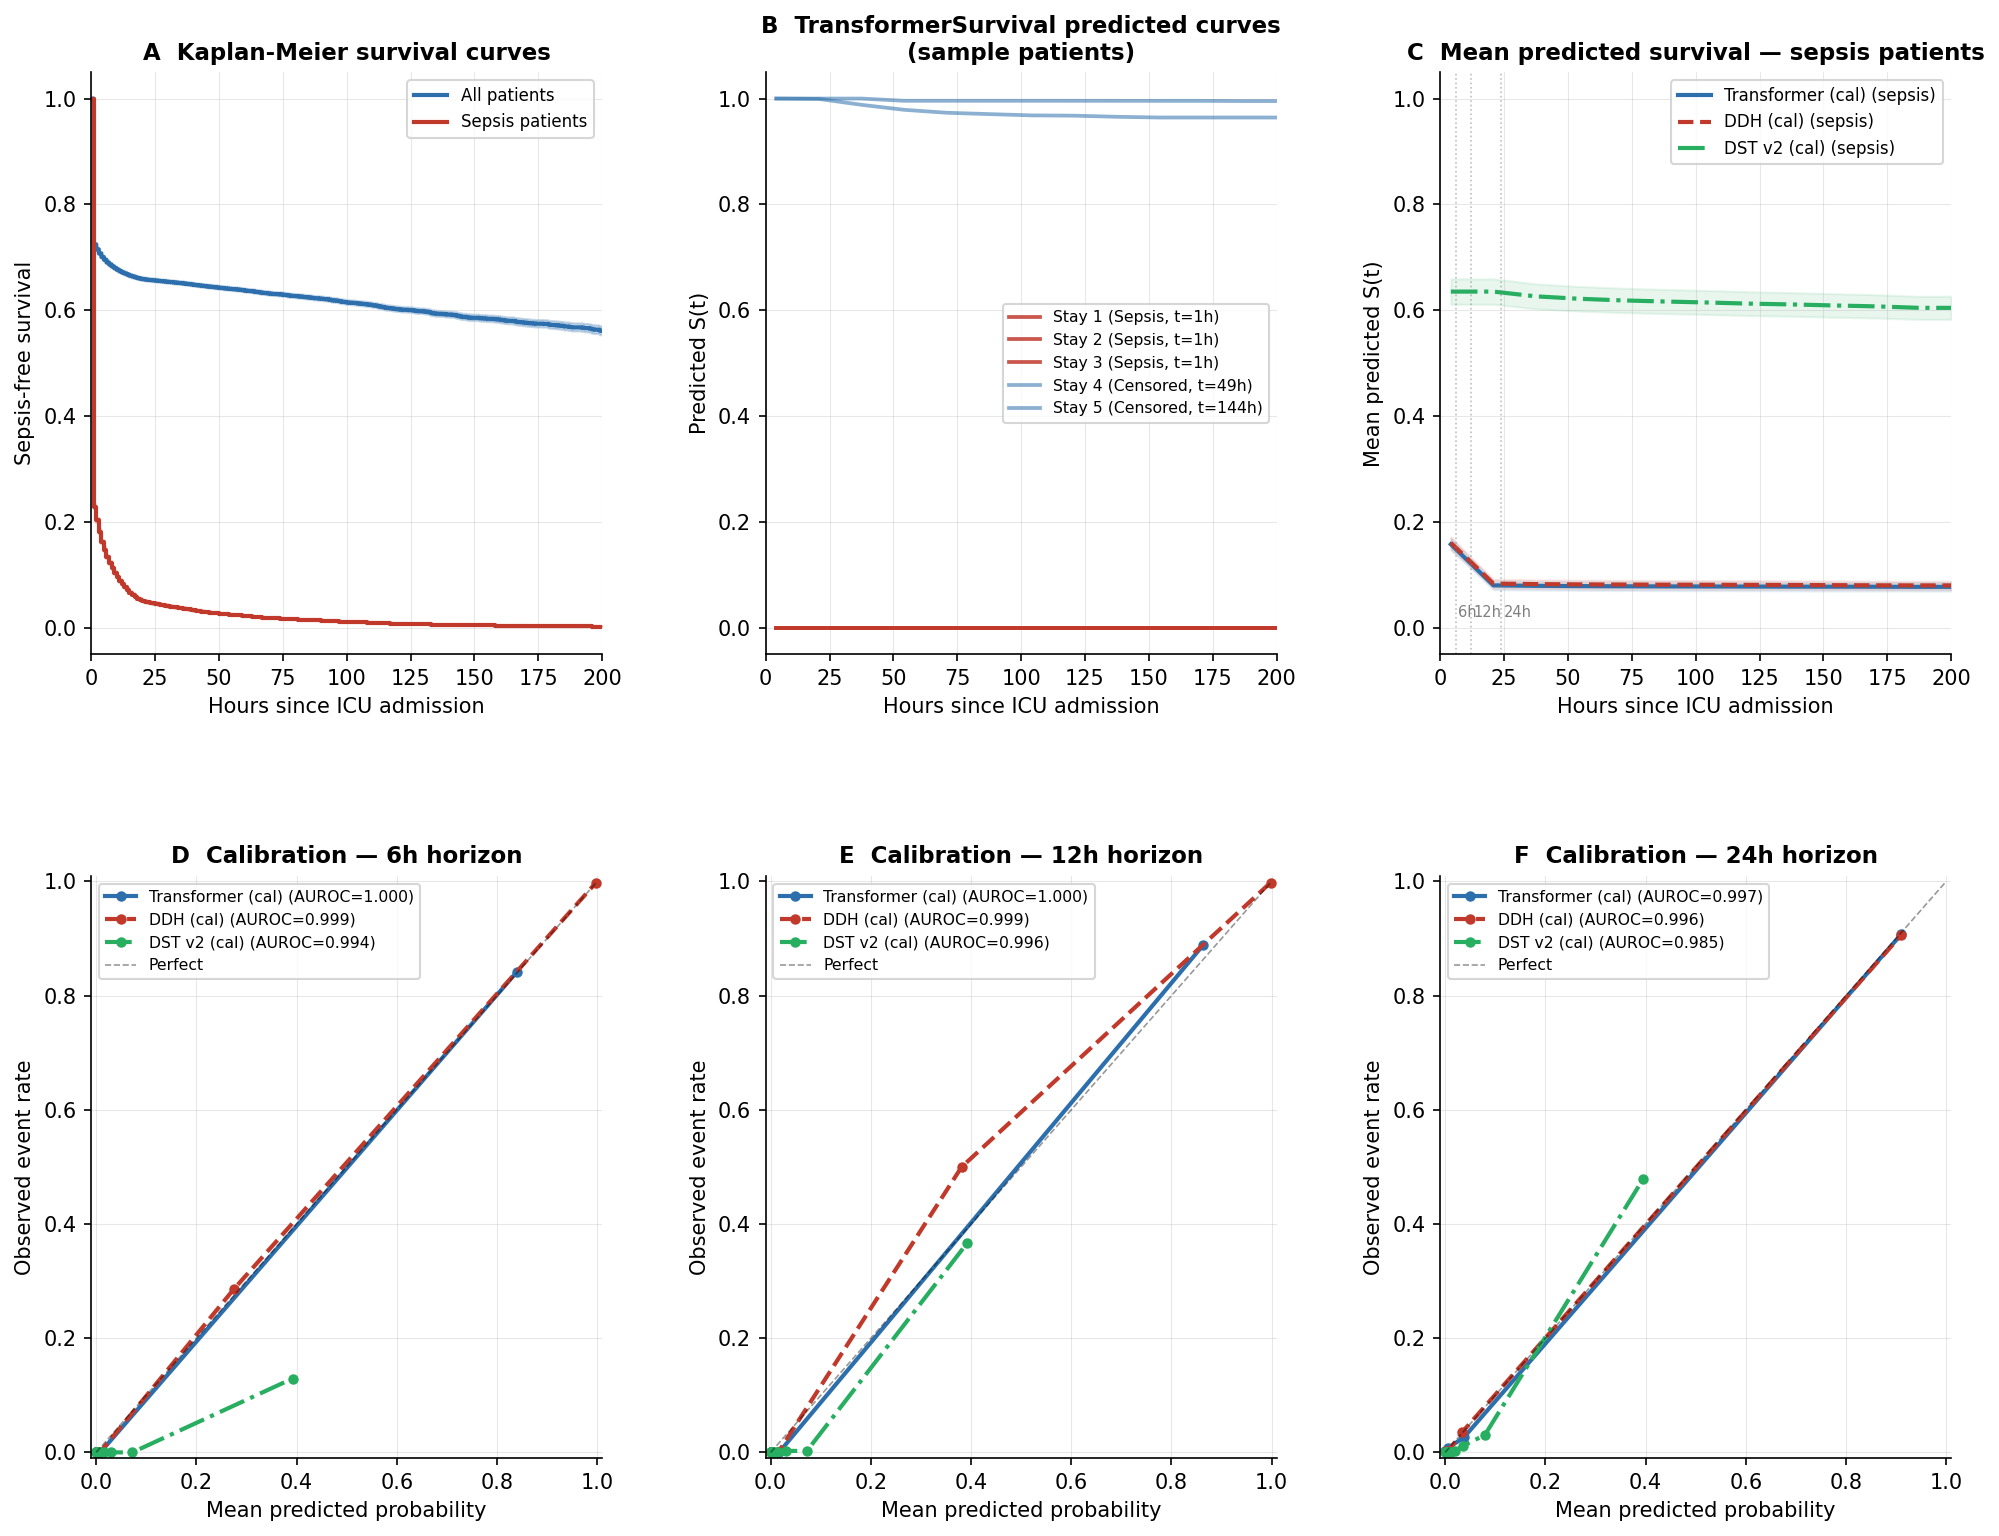

Saved -> fig2_survival_calibration.png ✓


In [36]:
# ── fig2: Survival & Calibration ─────────────────────────────
from lifelines import KaplanMeierFitter
print("Building fig2...")

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

COLORS = {
    'Transformer (cal)': '#2C6FAC',
    'DDH (cal)'        : '#C0392B',
    'DST v2 (cal)'     : '#27AE60',
}
LINESTYLES = {
    'Transformer (cal)': '-',
    'DDH (cal)'        : '--',
    'DST v2 (cal)'     : '-.',
}
model_configs = [
    ('Transformer (cal)', surv_t_all,   dur_t_all,   evt_t_all),
    ('DDH (cal)',         surv_ddh_all, dur_ddh_all, evt_ddh_all),
    ('DST v2 (cal)',      surv_dst_all, dur_dst_all, evt_dst_all),
]

# Panel A: KM curves
ax_km = fig.add_subplot(gs[0, 0])
kmf_all = KaplanMeierFitter()
kmf_all.fit(survival_df['duration'], event_observed=survival_df['event'],
            label='All patients')
kmf_all.plot_survival_function(ax=ax_km, color='#2C6FAC', lw=2, ci_show=True)
kmf_sep = KaplanMeierFitter()
sep_mask = survival_df['event'] == 1
kmf_sep.fit(survival_df.loc[sep_mask,'duration'],
            event_observed=survival_df.loc[sep_mask,'event'],
            label='Sepsis patients')
kmf_sep.plot_survival_function(ax=ax_km, color='#C0392B', lw=2, ci_show=True)
ax_km.set_xlabel('Hours since ICU admission', fontsize=10)
ax_km.set_ylabel('Sepsis-free survival', fontsize=10)
ax_km.set_title('A  Kaplan-Meier survival curves', fontsize=11, fontweight='bold')
ax_km.set_xlim(0, 200)
ax_km.legend(fontsize=8)

# Panel B: Predicted survival — sample patients
ax_surv = fig.add_subplot(gs[0, 1])
sep_idx = np.where(evt_t_all == 1)[0][:3]
cen_idx = np.where(evt_t_all == 0)[0][:2]
for i, idx in enumerate(np.concatenate([sep_idx, cen_idx])):
    label = 'Sepsis' if evt_t_all[idx]==1 else 'Censored'
    color = '#C0392B' if evt_t_all[idx]==1 else '#2C6FAC'
    alpha = 0.85 if evt_t_all[idx]==1 else 0.55
    ax_surv.plot(time_cuts, surv_t_all[idx], color=color, alpha=alpha,
                 lw=1.8, label=f'Stay {i+1} ({label}, t={dur_t_all[idx]:.0f}h)')
ax_surv.set_xlabel('Hours since ICU admission', fontsize=10)
ax_surv.set_ylabel('Predicted S(t)', fontsize=10)
ax_surv.set_title('B  TransformerSurvival predicted curves\n(sample patients)',
                  fontsize=11, fontweight='bold')
ax_surv.set_xlim(0, 200); ax_surv.set_ylim(-0.05, 1.05)
ax_surv.legend(fontsize=7.5)

# Panel C: Mean predicted survival
ax_mean = fig.add_subplot(gs[0, 2])
for model_name, surv, dur, evt in model_configs:
    mean_s = surv[evt==1].mean(axis=0)
    ci     = 1.96 * surv[evt==1].std(axis=0) / np.sqrt((evt==1).sum())
    ax_mean.plot(time_cuts, mean_s, color=COLORS[model_name],
                 ls=LINESTYLES[model_name], lw=2, label=f'{model_name} (sepsis)')
    ax_mean.fill_between(time_cuts, mean_s-ci, mean_s+ci,
                         color=COLORS[model_name], alpha=0.1)
for H in HORIZONS:
    ax_mean.axvline(H, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax_mean.text(H+1, 0.02, f'{H}h', fontsize=7, color='gray')
ax_mean.set_xlabel('Hours since ICU admission', fontsize=10)
ax_mean.set_ylabel('Mean predicted S(t)', fontsize=10)
ax_mean.set_title('C  Mean predicted survival — sepsis patients',
                  fontsize=11, fontweight='bold')
ax_mean.set_xlim(0, 200); ax_mean.set_ylim(-0.05, 1.05)
ax_mean.legend(fontsize=8)

# Panels D-F: Calibration curves
from sklearn.calibration import calibration_curve
for col_idx, H in enumerate(HORIZONS):
    ax_cal = fig.add_subplot(gs[1, col_idx])
    bin_H  = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS-1))
    for model_name, surv, dur, evt in model_configs:
        y_true  = ((evt==1) & (dur<=H)).astype(int)
        y_score = (1-surv[:,bin_H]).clip(0,1)
        if y_true.sum() < 10: continue
        frac, mean_pred = calibration_curve(y_true, y_score,
                                            n_bins=10, strategy='quantile')
        ax_cal.plot(mean_pred, frac, color=COLORS[model_name],
                    ls=LINESTYLES[model_name], lw=2, marker='o', ms=4,
                    label=f'{model_name} (AUROC={roc_auc_score(y_true,y_score):.3f})')
    ax_cal.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4,label='Perfect')
    ax_cal.set_xlabel('Mean predicted probability', fontsize=10)
    ax_cal.set_ylabel('Observed event rate', fontsize=10)
    ax_cal.set_title(f'{"DEF"[col_idx]}  Calibration — {H}h horizon',
                     fontsize=11, fontweight='bold')
    ax_cal.legend(fontsize=7.5)
    ax_cal.set_xlim(-0.01,1.01); ax_cal.set_ylim(-0.01,1.01)

plt.tight_layout()
fpath = FIG_DIR / 'fig2_survival_calibration.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

## Calibration all model

Building fig12...


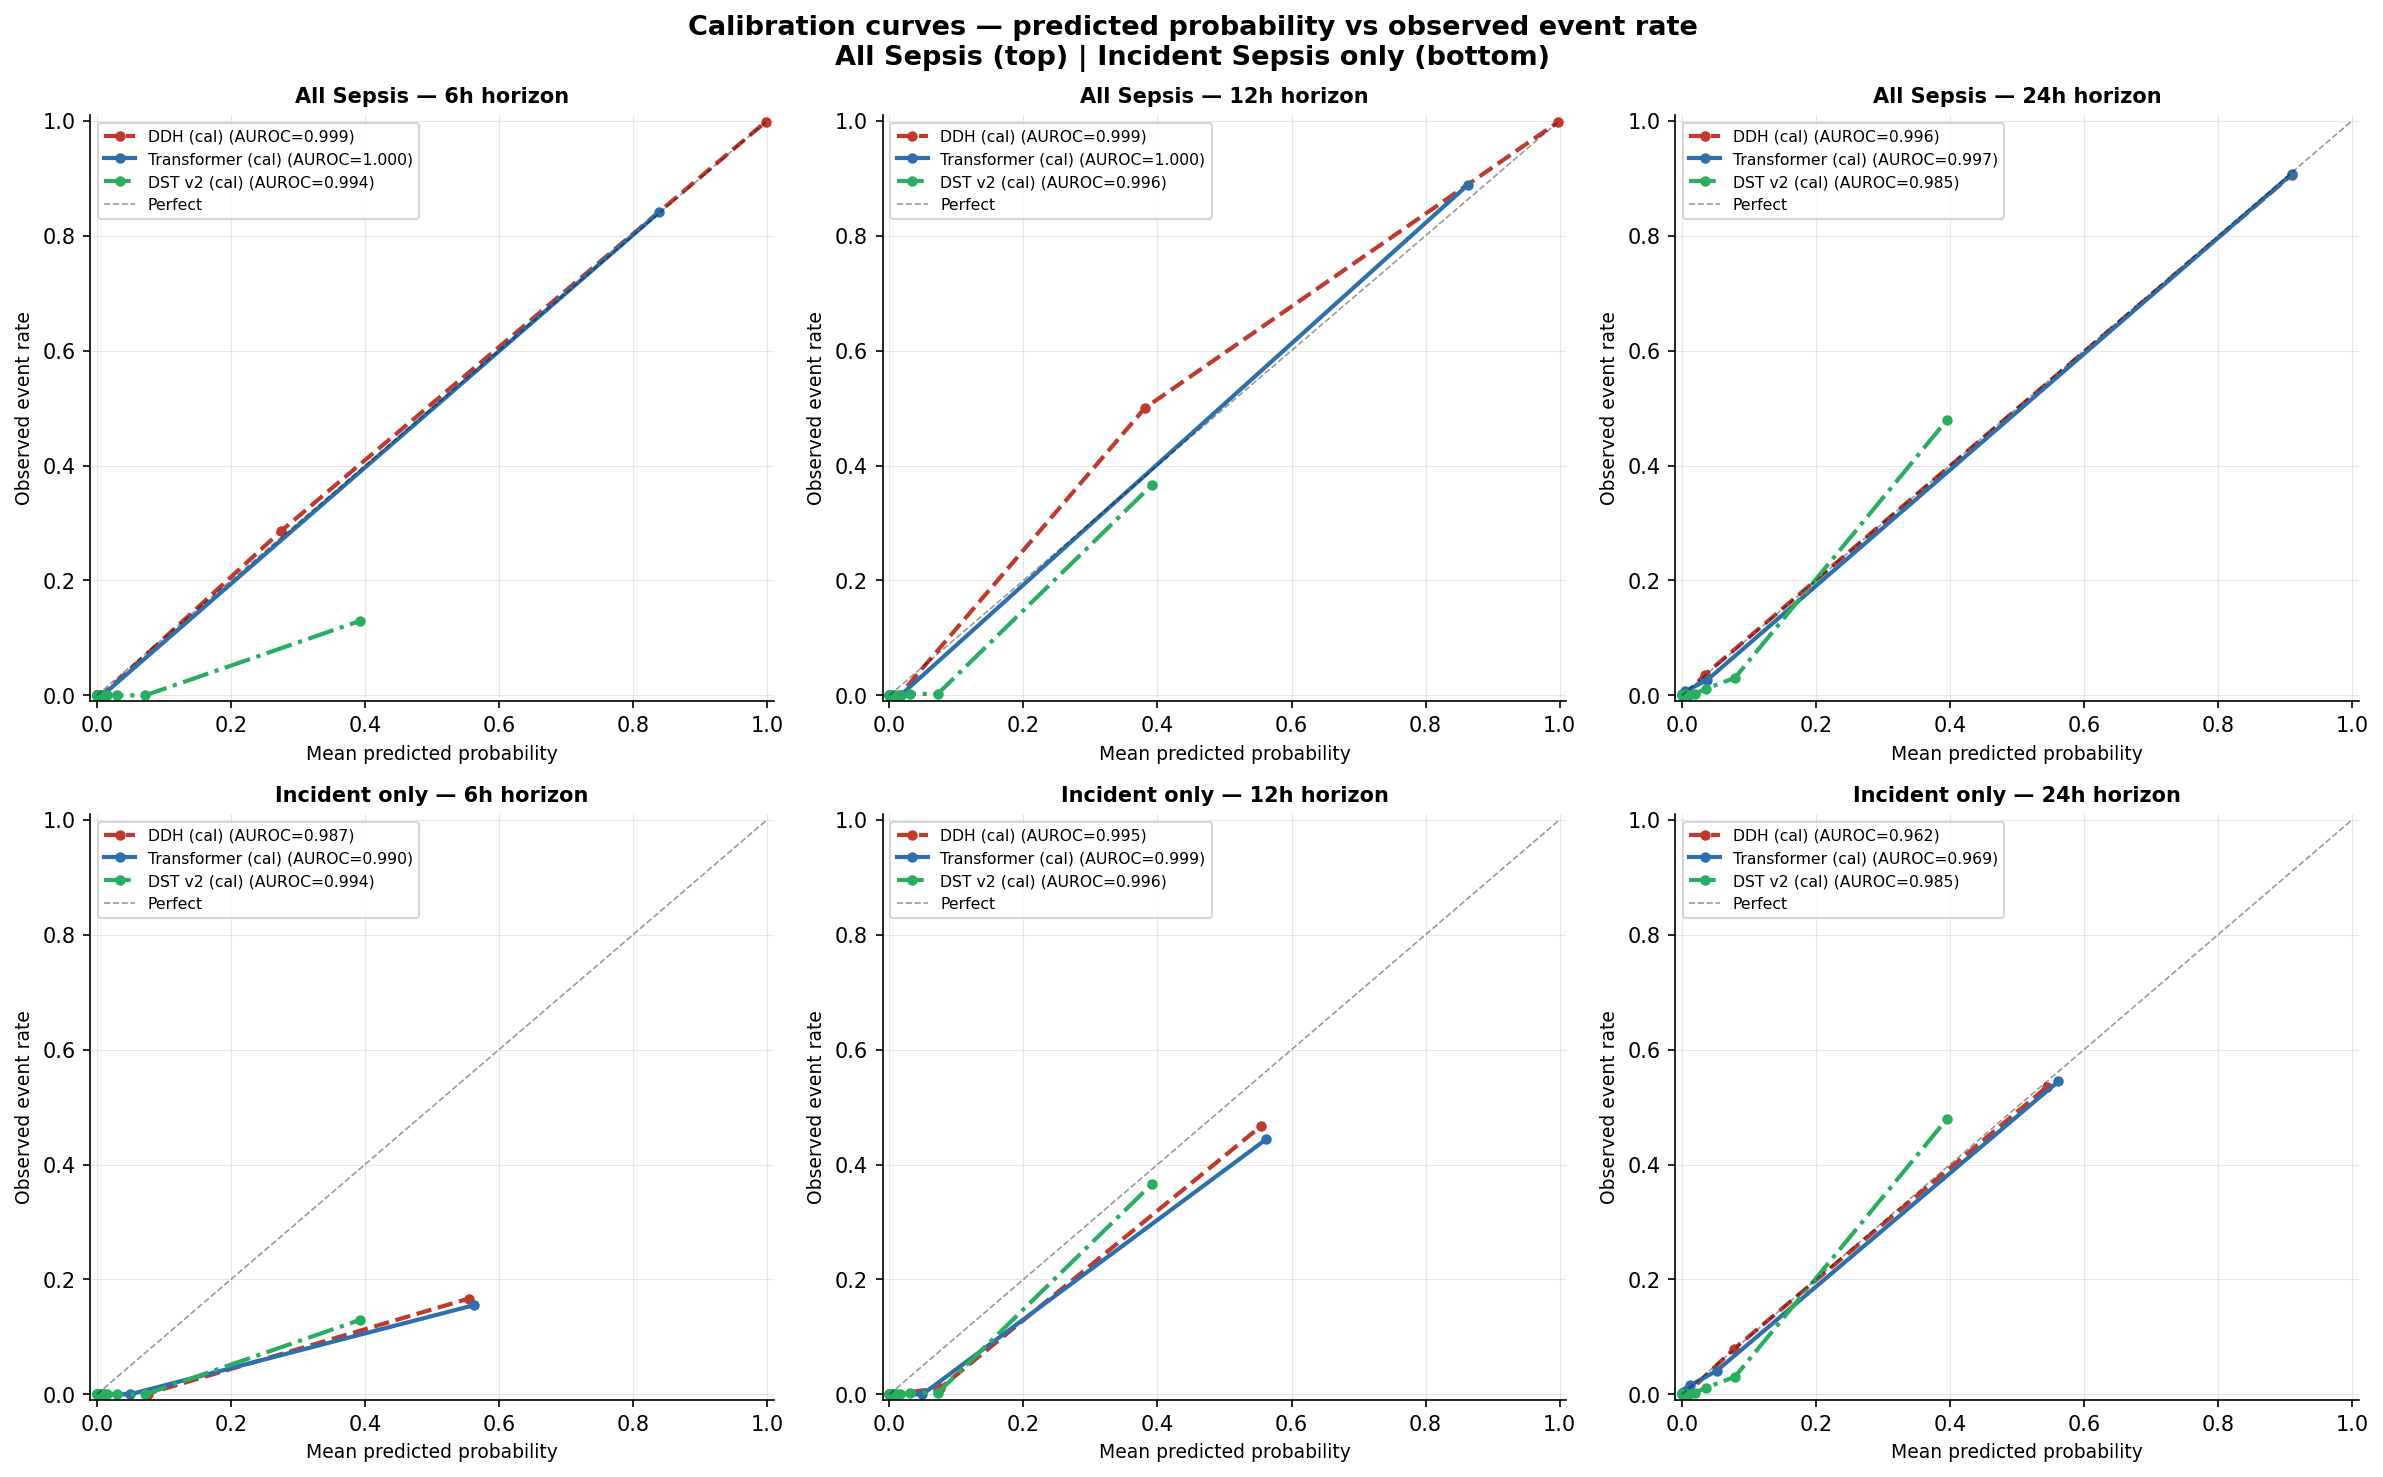

Saved -> fig12_calibration_all_models.png ✓


In [37]:
# ── fig12: Calibration all models ────────────────────────────
print("Building fig12...")
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Calibration curves — predicted probability vs observed event rate\n'
    'All Sepsis (top) | Incident Sepsis only (bottom)',
    fontsize=13, fontweight='bold'
)

configs_all = [
    ('DDH (cal)',         surv_ddh_all, dur_ddh_all, evt_ddh_all),
    ('Transformer (cal)', surv_t_all,   dur_t_all,   evt_t_all),
    ('DST v2 (cal)',      surv_dst_all, dur_dst_all, evt_dst_all),
]
configs_inc = [
    ('DDH (cal)',         surv_ddh_inc, dur_t_inc,   evt_t_inc),
    ('Transformer (cal)', surv_t_inc,   dur_t_inc,   evt_t_inc),
    ('DST v2 (cal)',      surv_dst_inc, dur_dst_inc, evt_dst_inc),
]

for row_idx, (configs, row_label) in enumerate([
    (configs_all, 'All Sepsis'),
    (configs_inc, 'Incident only'),
]):
    for col_idx, H in enumerate(HORIZONS):
        ax    = axes[row_idx, col_idx]
        bin_H = int(np.clip(np.searchsorted(time_cuts, H, 'right'), 0, NUM_BINS-1))
        for model_name, surv, dur, evt in configs:
            y_true  = ((evt==1) & (dur<=H)).astype(int)
            y_score = (1-surv[:,bin_H]).clip(0,1)
            if y_true.sum() < 10: continue
            frac, mean_pred = calibration_curve(y_true, y_score,
                                                n_bins=10, strategy='quantile')
            auroc = roc_auc_score(y_true, y_score)
            ax.plot(mean_pred, frac, color=COLORS[model_name],
                    ls=LINESTYLES[model_name], lw=2, marker='o', ms=4,
                    label=f'{model_name} (AUROC={auroc:.3f})')
        ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4,label='Perfect')
        ax.set_xlabel('Mean predicted probability', fontsize=9)
        ax.set_ylabel('Observed event rate', fontsize=9)
        ax.set_title(f'{row_label} — {H}h horizon',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=7.5)
        ax.set_xlim(-0.01,1.01); ax.set_ylim(-0.01,1.01)

plt.tight_layout()
fpath = FIG_DIR / 'fig12_calibration_all_models.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

## KM vs Predicted

Building fig13...


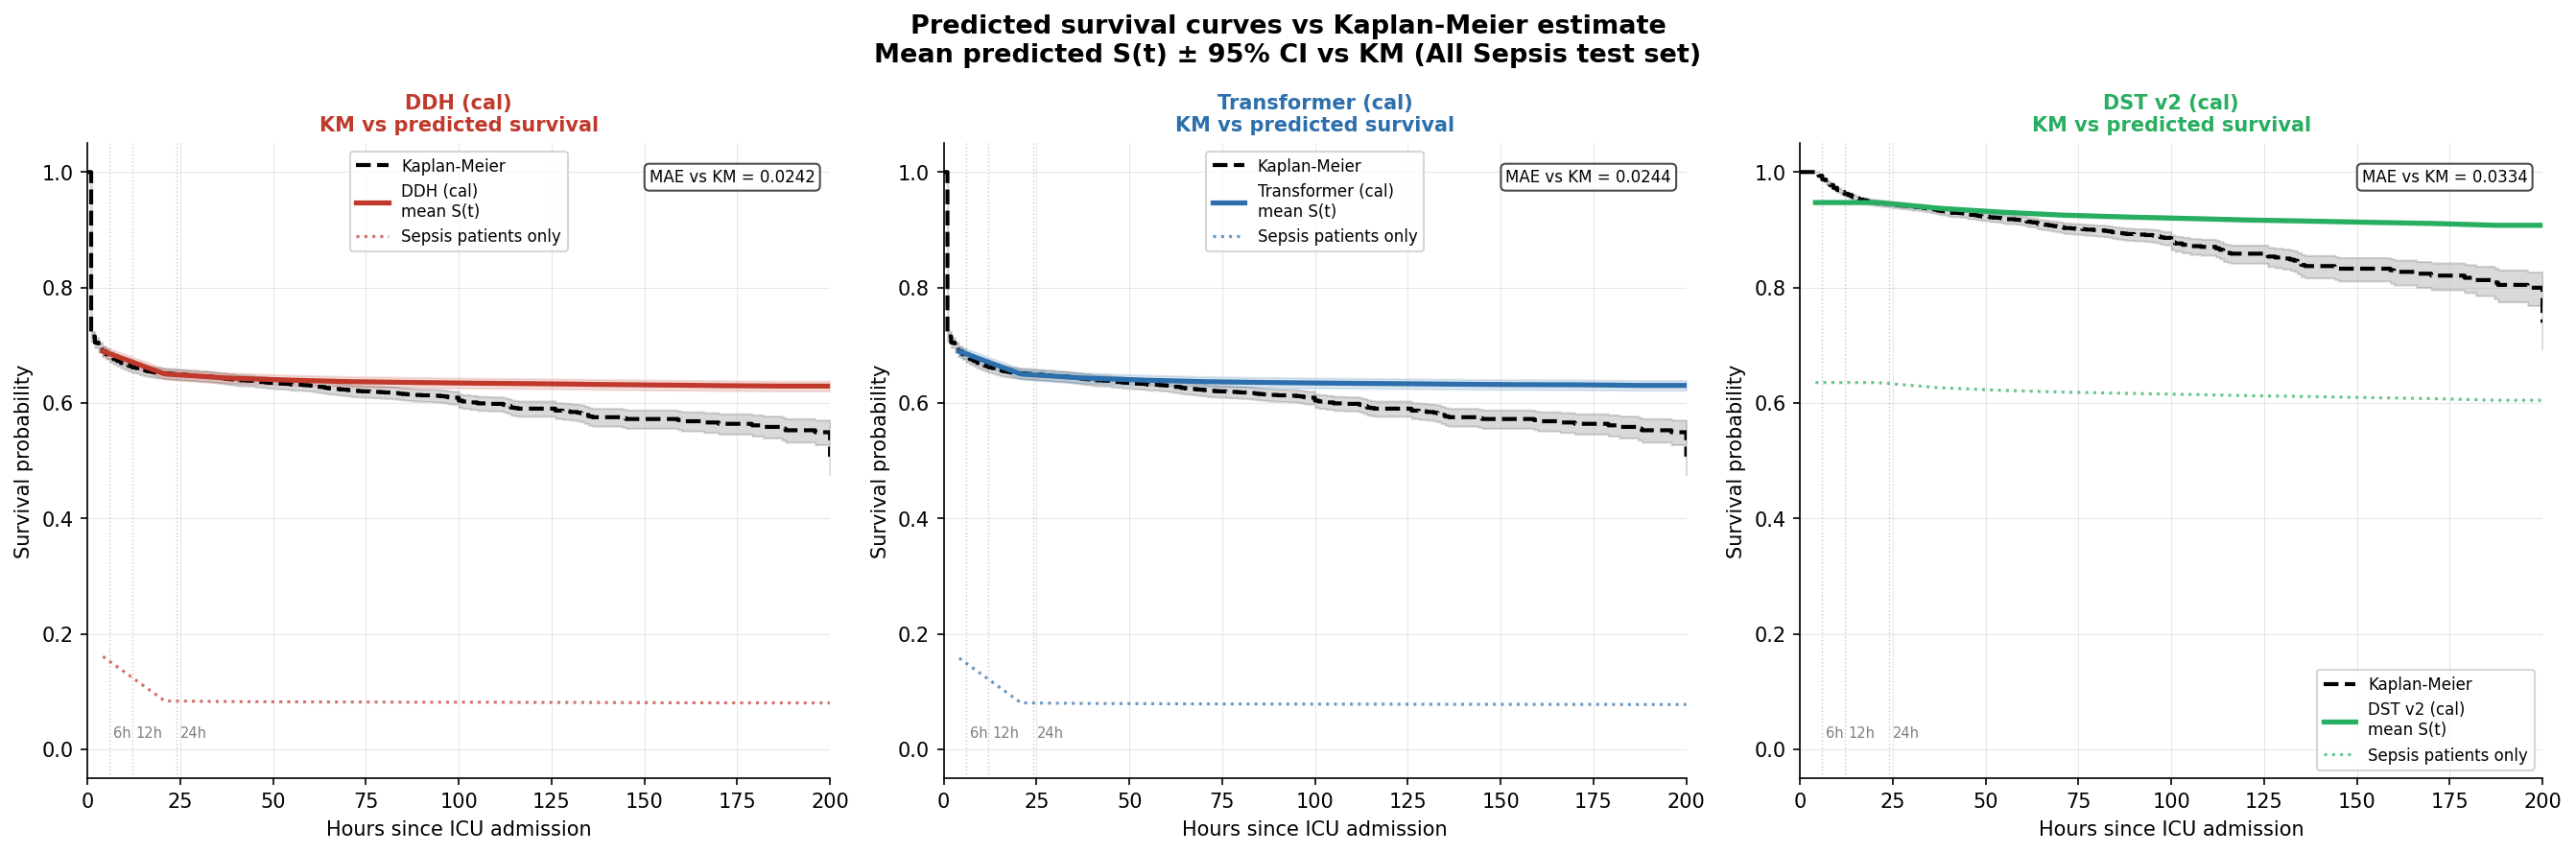

Saved -> fig13_km_vs_predicted.png ✓


In [38]:
# ── fig13: KM vs predicted survival ──────────────────────────
print("Building fig13...")
from lifelines import KaplanMeierFitter

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Predicted survival curves vs Kaplan-Meier estimate\n'
    'Mean predicted S(t) ± 95% CI vs KM (All Sepsis test set)',
    fontsize=13, fontweight='bold'
)

configs_km = [
    ('DDH (cal)',         surv_ddh_all, dur_ddh_all, evt_ddh_all, '#C0392B'),
    ('Transformer (cal)', surv_t_all,   dur_t_all,   evt_t_all,   '#2C6FAC'),
    ('DST v2 (cal)',      surv_dst_all, dur_dst_all, evt_dst_all, '#27AE60'),
]

for col_idx, (model_name, surv, dur, evt, color) in enumerate(configs_km):
    ax = axes[col_idx]
    kmf = KaplanMeierFitter()
    kmf.fit(dur, event_observed=evt, label='Kaplan-Meier')
    kmf.plot_survival_function(ax=ax, color='black', lw=2,
                               ci_show=True, ci_alpha=0.15, ls='--')
    mean_surv = surv.mean(axis=0)
    ci        = 1.96 * surv.std(axis=0) / np.sqrt(len(surv))
    ax.plot(time_cuts, mean_surv, color=color, lw=2.5,
            label=f'{model_name}\nmean S(t)')
    ax.fill_between(time_cuts, mean_surv-ci, mean_surv+ci,
                    color=color, alpha=0.15)
    sep_mask      = evt == 1
    mean_surv_sep = surv[sep_mask].mean(axis=0)
    ax.plot(time_cuts, mean_surv_sep, color=color, lw=1.5,
            ls=':', alpha=0.7, label=f'Sepsis patients only')
    for H in HORIZONS:
        ax.axvline(H, color='gray', lw=0.7, ls=':', alpha=0.4)
        ax.text(H+1, 0.02, f'{H}h', fontsize=7, color='gray')
    km_timeline  = kmf.survival_function_.index.values
    km_surv_vals = kmf.survival_function_.iloc[:,0].values
    pred_at_km   = np.interp(km_timeline, time_cuts, mean_surv)
    mae          = np.mean(np.abs(pred_at_km - km_surv_vals))
    ax.text(0.98, 0.96, f'MAE vs KM = {mae:.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.set_xlabel('Hours since ICU admission', fontsize=10)
    ax.set_ylabel('Survival probability', fontsize=10)
    ax.set_title(f'{model_name}\nKM vs predicted survival',
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlim(0, 200); ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
fpath = FIG_DIR / 'fig13_km_vs_predicted.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

## Contrasting cases

Building fig14...


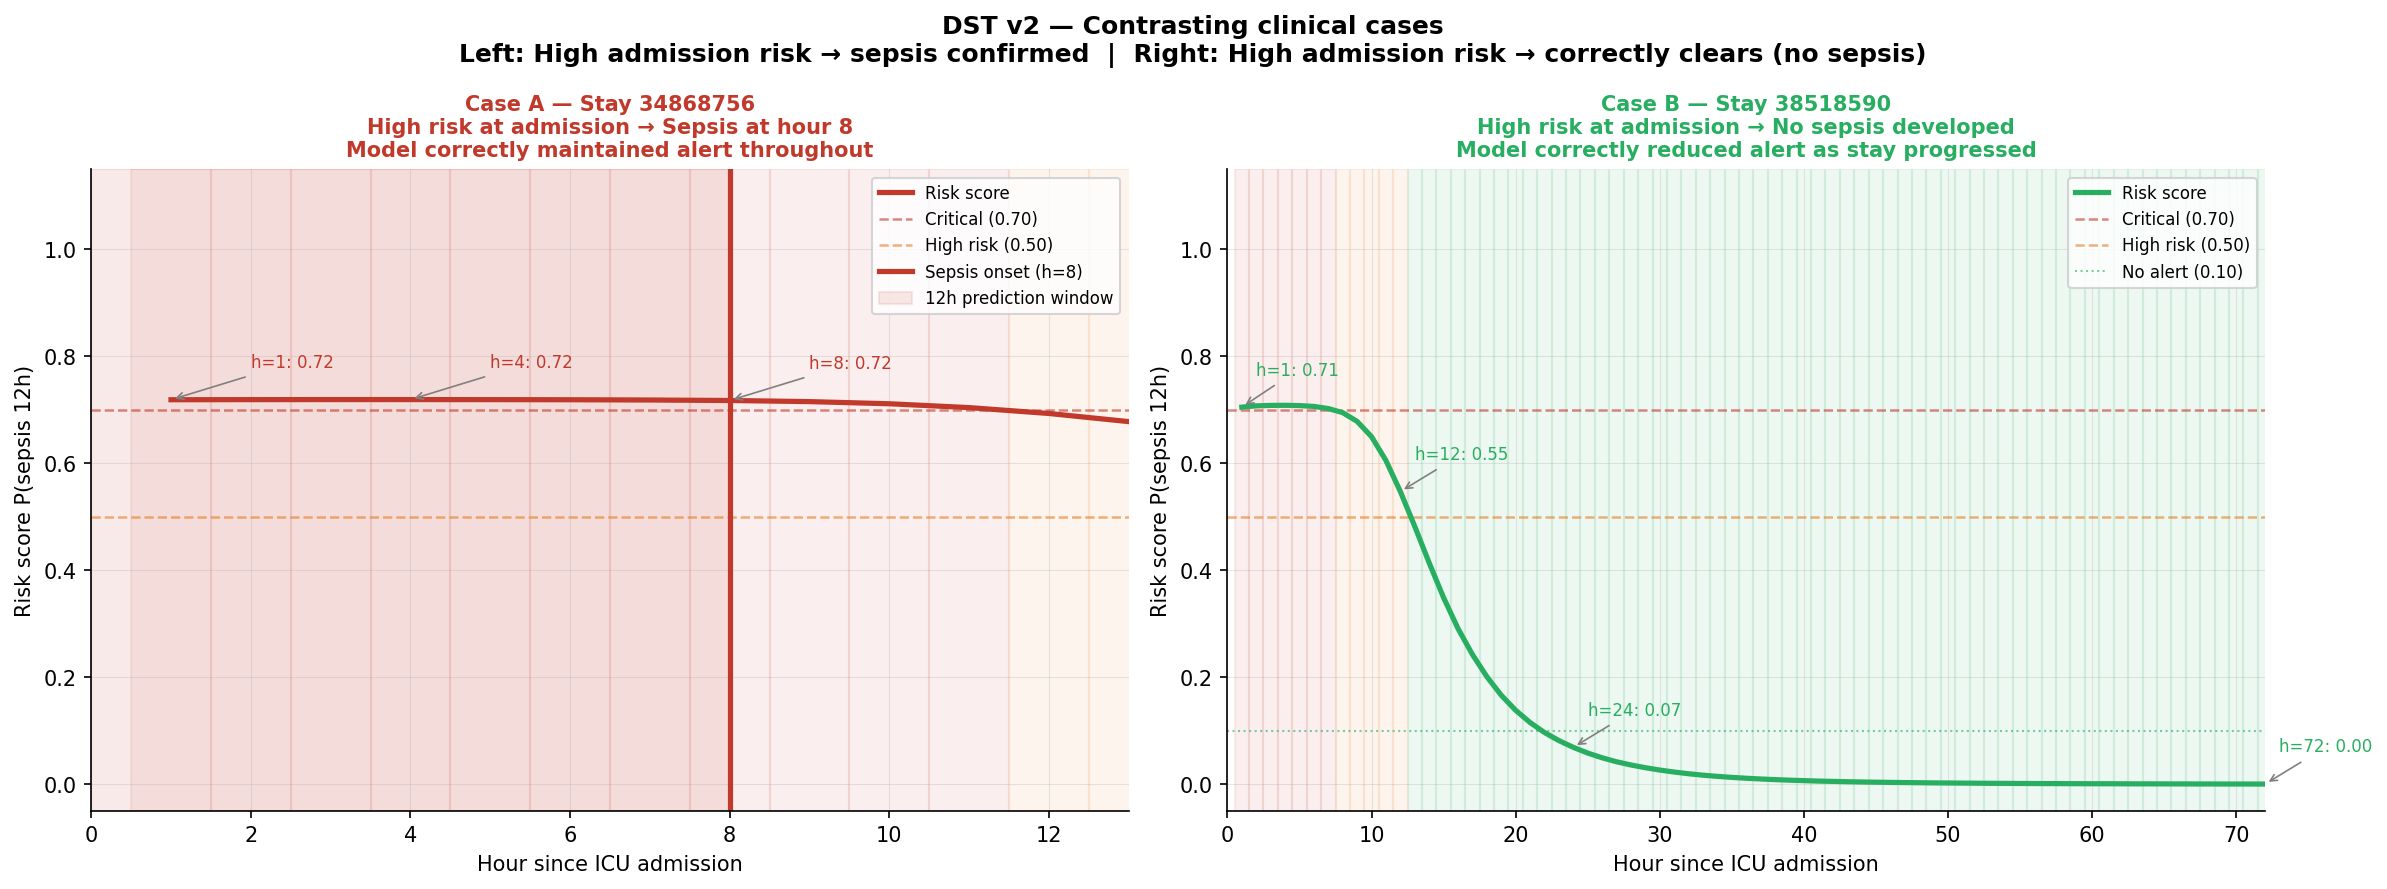

Saved -> fig14_contrasting_cases.png ✓


In [39]:
# ── fig14: Contrasting cases ──────────────────────────────────
print("Building fig14...")

test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)].copy()
tier_colors_map = {
    'no_alert' : '#27AE60',
    'high_risk': '#E67E22',
    'critical' : '#C0392B',
}

# Case A: high risk → sepsis
case_a_candidates = []
for sid in test_inc['stay_id'].unique():
    onset = onset_lookup.get(sid)
    if onset is None or onset < 8 or onset > 60: continue
    stay  = test_inc[test_inc['stay_id']==sid].sort_values('hour')
    if len(stay) < onset + 6: continue
    early = stay[stay['hour'] <= 3]['risk_score']
    pre   = stay[stay['hour'].between(max(1,onset-6),onset)]['risk_score']
    if len(early)==0 or early.mean()<0.40: continue
    if len(pre)==0 or pre.mean()<0.30: continue
    case_a_candidates.append((sid, onset, early.mean()+pre.mean()))
case_a_candidates = sorted(case_a_candidates, key=lambda x: x[2], reverse=True)

# Case B: use stay 38518590 — our best no-sepsis example
sid_b  = 38518590
stay_b = test_inc[test_inc['stay_id']==sid_b].sort_values('hour')

if len(case_a_candidates) == 0:
    for sid in test_inc['stay_id'].unique():
        onset = onset_lookup.get(sid)
        if onset is None or onset < 5: continue
        stay  = test_inc[test_inc['stay_id']==sid].sort_values('hour')
        early = stay[stay['hour']<=3]['risk_score']
        if len(early)==0 or early.mean()<0.30: continue
        case_a_candidates.append((sid, onset, early.mean()))
    case_a_candidates = sorted(case_a_candidates, key=lambda x: x[2], reverse=True)

sid_a, onset_a = case_a_candidates[0][0], case_a_candidates[0][1]
stay_a = test_inc[test_inc['stay_id']==sid_a].sort_values('hour')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'DST v2 — Contrasting clinical cases\n'
    'Left: High admission risk → sepsis confirmed  |  '
    'Right: High admission risk → correctly clears (no sepsis)',
    fontsize=12, fontweight='bold'
)

# Panel A
ax = axes[0]
for _, row in stay_a.iterrows():
    ax.axvspan(row['hour']-0.5, row['hour']+0.5, alpha=0.08,
               color=tier_colors_map.get(row['alert_tier'],'gray'))
ax.plot(stay_a['hour'], stay_a['risk_score'],
        color='#C0392B', lw=2.5, zorder=3, label='Risk score')
ax.axhline(0.70, color='#C0392B', lw=1.2, ls='--', alpha=0.6, label='Critical (0.70)')
ax.axhline(0.50, color='#E67E22', lw=1.2, ls='--', alpha=0.6, label='High risk (0.50)')
ax.axvline(onset_a, color='#C0392B', lw=2.5, label=f'Sepsis onset (h={onset_a})')
ax.axvspan(max(0,onset_a-12), onset_a, alpha=0.10,
           color='#C0392B', label='12h prediction window')
for h_ann in [1, onset_a//2, onset_a]:
    r = stay_a[stay_a['hour']==h_ann]
    if len(r)>0:
        v = r['risk_score'].values[0]
        ax.annotate(f'h={h_ann}: {v:.2f}', xy=(h_ann,v),
                    xytext=(h_ann+1, min(v+0.06,1.05)), fontsize=8,
                    color='#C0392B',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.set_xlim(0, min(stay_a['hour'].max(), onset_a+12))
ax.set_ylim(-0.05,1.15)
ax.set_xlabel('Hour since ICU admission', fontsize=10)
ax.set_ylabel('Risk score P(sepsis 12h)', fontsize=10)
ax.set_title(f'Case A — Stay {sid_a}\nHigh risk at admission → Sepsis at hour {onset_a}\n'
             f'Model correctly maintained alert throughout',
             fontsize=10, fontweight='bold', color='#C0392B')
ax.legend(fontsize=8, loc='upper right')

# Panel B
ax    = axes[1]
x_max = min(stay_b['hour'].max(), 72)
sb    = stay_b[stay_b['hour']<=x_max]
for _, row in sb.iterrows():
    ax.axvspan(row['hour']-0.5, row['hour']+0.5, alpha=0.08,
               color=tier_colors_map.get(row['alert_tier'],'gray'))
ax.plot(sb['hour'], sb['risk_score'],
        color='#27AE60', lw=2.5, zorder=3, label='Risk score')
ax.axhline(0.70, color='#C0392B', lw=1.2, ls='--', alpha=0.6, label='Critical (0.70)')
ax.axhline(0.50, color='#E67E22', lw=1.2, ls='--', alpha=0.6, label='High risk (0.50)')
ax.axhline(0.10, color='#27AE60', lw=1.0, ls=':', alpha=0.6, label='No alert (0.10)')
for h_ann in [1, 12, 24, x_max]:
    r = sb[sb['hour']==h_ann]
    if len(r)>0:
        v = r['risk_score'].values[0]
        ax.annotate(f'h={h_ann}: {v:.2f}', xy=(h_ann,v),
                    xytext=(h_ann+1, min(v+0.06,1.05)), fontsize=8,
                    color='#27AE60',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.set_xlim(0, x_max)
ax.set_ylim(-0.05,1.15)
ax.set_xlabel('Hour since ICU admission', fontsize=10)
ax.set_ylabel('Risk score P(sepsis 12h)', fontsize=10)
ax.set_title(f'Case B — Stay {sid_b}\nHigh risk at admission → No sepsis developed\n'
             f'Model correctly reduced alert as stay progressed',
             fontsize=10, fontweight='bold', color='#27AE60')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
fpath = FIG_DIR / 'fig14_contrasting_cases.png'
plt.savefig(str(fpath), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {fpath.name} ✓')

## Canonical Result table

In [40]:
# ── Canonical results table ───────────────────────────────────
print("Building canonical results table...")

canon_rows = []
for _, br in bootstrap_df.iterrows():
    model   = br['Model']
    dataset = br['Dataset']
    if 'DST' in model:
        surv, dur, evt = (surv_dst_inc, dur_dst_inc, evt_dst_inc) \
            if dataset == 'Incident' else \
            (surv_dst_all, dur_dst_all, evt_dst_all)
    elif 'DDH' in model:
        surv, dur, evt = (surv_ddh_inc, dur_t_inc, evt_t_inc) \
            if dataset == 'Incident' else \
            (surv_ddh_all, dur_ddh_all, evt_ddh_all)
    else:
        surv, dur, evt = (surv_t_inc, dur_t_inc, evt_t_inc) \
            if dataset == 'Incident' else \
            (surv_t_all, dur_t_all, evt_t_all)

    row = {
        'Model'         : model,
        'Dataset'       : dataset,
        'N_test'        : br['N_test'],
        'N_events'      : br['N_events'],
        'Event_rate_%'  : round(br['Event_rate']*100, 1),
        'C-index'       : br['C-index'],
        'C-index_95CI'  : f"[{br['CI_lo']:.4f}–{br['CI_hi']:.4f}]",
        'IBS'           : br['IBS'],
        'IBS_95CI'      : f"[{br['IBS_lo']:.4f}–{br['IBS_hi']:.4f}]",
    }
    for H in HORIZONS:
        bin_H   = int(np.clip(np.searchsorted(time_cuts,H,'right'),0,NUM_BINS-1))
        y_true  = ((evt==1)&(dur<=H)).astype(int)
        y_score = (1-surv[:,bin_H]).clip(0,1)
        if y_true.sum()>=5:
            row[f'AUROC@{H}h'] = round(roc_auc_score(y_true,y_score),4)
            row[f'AUPRC@{H}h'] = round(average_precision_score(y_true,y_score),4)
        else:
            row[f'AUROC@{H}h'] = None
            row[f'AUPRC@{H}h'] = None
    canon_rows.append(row)

canon_df = pd.DataFrame(canon_rows)
canon_df.to_csv(str(OUTPUT_DIR / 'canonical_results_table.csv'), index=False)

try:
    with pd.ExcelWriter(str(OUTPUT_DIR / 'canonical_results_table.xlsx'),
                        engine='openpyxl') as writer:
        canon_df.to_excel(writer, sheet_name='All Models', index=False)
        bootstrap_df.to_excel(writer, sheet_name='Bootstrap CIs', index=False)
    print('Saved -> canonical_results_table.xlsx ✓')
except Exception as e:
    print(f'Excel skipped: {e}')

print(f'\n{"="*95}')
print('CANONICAL RESULTS TABLE — AI-SEPSIS')
print(f'{"="*95}')
print(f'{"Model":<22} {"Dataset":<12} {"N":>6} {"Events":>7} '
      f'{"C-index":>8} {"95% CI":>18} {"IBS":>7} '
      f'{"AUROC@6h":>9} {"AUROC@12h":>10} {"AUROC@24h":>10}')
print('-'*95)
for _, row in canon_df.iterrows():
    print(f'{row["Model"]:<22} {row["Dataset"]:<12} '
          f'{row["N_test"]:>6,} {row["N_events"]:>7,} '
          f'{row["C-index"]:>8.4f} {row["C-index_95CI"]:>18} '
          f'{row["IBS"]:>7.4f} '
          f'{str(row.get("AUROC@6h","—")):>9} '
          f'{str(row.get("AUROC@12h","—")):>10} '
          f'{str(row.get("AUROC@24h","—")):>10}')
print(f'{"="*95}')
print('\n04 complete ✓')
print(f'All figures saved to: {FIG_DIR}')
print(f'\nFigures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')

Building canonical results table...
Saved -> canonical_results_table.xlsx ✓

CANONICAL RESULTS TABLE — AI-SEPSIS
Model                  Dataset           N  Events  C-index             95% CI     IBS  AUROC@6h  AUROC@12h  AUROC@24h
-----------------------------------------------------------------------------------------------
DDH (cal)              Incident      7,310     618   0.9245    [0.9120–0.9355]  0.0528    0.9868     0.9953     0.9622
DDH (cal)              All Sepsis   10,604   3,912   0.9492    [0.9460–0.9526]  0.0114    0.9993     0.9994     0.9964
Transformer (cal)      Incident      7,310     618   0.9314    [0.9189–0.9425]  0.0484    0.9899     0.9995      0.969
Transformer (cal)      All Sepsis   10,604   3,912   0.9822    [0.9806–0.9839]  0.0104    0.9999        1.0     0.9968
DST v2 (cal)           Incident      7,887     620   0.9790    [0.9760–0.9818]  0.0477    0.9935     0.9963     0.9854
DST v2 (cal)           All Sepsis    7,887     620   0.9790    [0.9759–0.9815